In [97]:
import math
import os
import re
import sys
from pathlib import Path

import ipywidgets as widgets
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from data_profiling import ProfileReport
from ipywidgets import interact
from matplotlib.widgets import Button
from rapidfuzz import fuzz, process
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

%matplotlib widget

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.constants import POPULATION_DATA, INFLATION_DATA, NUMBER_OF_DAYS_OF_WEEK, NUMBER_OF_DAYS_IN_MONTH, NUMBER_OF_DAYS_OF_MONTH, CLUSTERS_OF_ITEMS

root = Path.cwd().parent
raw_data_path = root / "data" / "raw"

# Data Loading and Quality Check

This work uses the Kaggle competition dataset “Predict Future Sales”.

https://www.kaggle.com/competitions/competitive-data-science-predict-future-sales/overview

The dataset consists of 4 tables:

- Sales history
- Item data
- Item categories
- Shops

These tables will later be merged to provide more information for the analysis.

In [2]:
train = pd.read_csv(raw_data_path / "sales_train.csv")
items = pd.read_csv(raw_data_path / "items.csv")
item_cats = pd.read_csv(raw_data_path / "item_categories.csv")
shops = pd.read_csv(raw_data_path / "shops.csv")
test = pd.read_csv(raw_data_path / "test.csv")

## Train

In [3]:
train.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  object 
 1   date_block_num  2935849 non-null  int64  
 2   shop_id         2935849 non-null  int64  
 3   item_id         2935849 non-null  int64  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  float64
dtypes: float64(2), int64(3), object(1)
memory usage: 134.4+ MB


In [4]:
train.shape

(2935849, 6)

There are millions of records in `train`, with no missing values.

The table consists of the following fields:

- dates
- number of months since January 2013
- shop ID
- product ID
- product price
- number of units sold

Let's check for duplicates.

In [5]:
duplicates = train[train.duplicated(keep=False)]
duplicates

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
76961,05.01.2013,0,54,20130,149.0,1.0
76962,05.01.2013,0,54,20130,149.0,1.0
1435365,23.02.2014,13,50,3423,999.0,1.0
1435367,23.02.2014,13,50,3423,999.0,1.0
1496765,23.03.2014,14,21,3423,999.0,1.0
1496766,23.03.2014,14,21,3423,999.0,1.0
1671872,01.05.2014,16,50,3423,999.0,1.0
1671873,01.05.2014,16,50,3423,999.0,1.0
1866322,12.07.2014,18,25,3423,999.0,1.0
1866340,12.07.2014,18,25,3423,999.0,1.0


One item appears very frequently across different shops.

In [6]:
items[items["item_id"] == 3423]

,item_name,item_id,item_category_id
3423,"Far Cry 3 (Classics) [Xbox 360, русская версия]",3423,23


In [7]:
train = train.drop_duplicates(keep='first')

In this dataset, each record represents the total sales for a day. Therefore, when duplicates occur, they are most likely data errors rather than two separate sales on the same day.

In [8]:
train['date'] = pd.to_datetime(train['date'], format='%d.%m.%Y')
train["year"] = train["date"].dt.year
train["month"] = train["date"].dt.month
train["month_day"] = train["date"].dt.day
train["week_day"] = train["date"].dt.day_of_week
train["month_day_sin"] = np.sin(2 * np.pi * train["month_day"] / train["date"].dt.days_in_month)
train["month_day_cos"] = np.cos(2 * np.pi * train["month_day"] / train["date"].dt.days_in_month)
train["month_sin"] = np.sin(2 * np.pi * train["month"] / 12)
train["month_cos"] = np.cos(2 * np.pi * train["month"] / 12)
train["week_day_sin"] = np.sin(2 * np.pi * train["week_day"] / 7)
train["week_day_cos"] = np.cos(2 * np.pi * train["week_day"] / 7)

The date field was converted to the `datetime` format.

- year field added
- month field added
- day of month field added
- day of week field added

In [9]:
train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,year,month,month_day,week_day,month_day_sin,month_day_cos,month_sin,month_cos,week_day_sin,week_day_cos
0,2013-01-02,0,59,22154,999.00,1.0,2013,1,2,2,0.394356,0.918958,0.5,0.866025,0.974928,-0.222521
1,2013-01-03,0,25,2552,899.00,1.0,2013,1,3,3,0.571268,0.820763,0.5,0.866025,0.433884,-0.900969
2,2013-01-05,0,25,2552,899.00,-1.0,2013,1,5,5,0.848644,0.528964,0.5,0.866025,-0.974928,-0.222521
3,2013-01-06,0,25,2554,1709.05,1.0,2013,1,6,6,0.937752,0.347305,0.5,0.866025,-0.781831,0.623490
4,2013-01-15,0,25,2555,1099.00,1.0,2013,1,15,1,0.101168,-0.994869,0.5,0.866025,0.781831,0.623490


In [10]:
expected_value = (train["year"] - 2013) * 12 + (train['month']- 1)
print(any(expected_value != train["date_block_num"]))

False


The `date_block_num` field is consistent with expectations.

In [ ]:
train['inflation_factor'] = train.set_index(['year', 'month']).index.map(INFLATION_DATA)
train['no_inflation_price'] = train['item_price'] / train['inflation_factor']

Let's add an annual inflation coefficient to work with prices more accurately.

Annual inflation coefficients based on ROSSTAT data were added for all years. For 2015, coefficients were added only up to October to stay within the dataset period.

## Items

In [12]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   item_name         22170 non-null  object
 1   item_id           22170 non-null  int64 
 2   item_category_id  22170 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 519.7+ KB


In [13]:
items.shape

(22170, 3)

In [14]:
sorted(items["item_name"].unique())

['! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.)         D',
 '!ABBYY FineReader 12 Professional Edition Full [PC, Цифровая версия]',
 '***В ЛУЧАХ СЛАВЫ   (UNV)                    D',
 '***ГОЛУБАЯ ВОЛНА  (Univ)                      D',
 '***КОРОБКА (СТЕКЛО)                       D',
 '***НОВЫЕ АМЕРИКАНСКИЕ ГРАФФИТИ  (UNI)             D',
 '***УДАР ПО ВОРОТАМ (UNI)               D',
 '***УДАР ПО ВОРОТАМ-2 (UNI)               D',
 '***ЧАЙ С МУССОЛИНИ                     D',
 '***ШУГАРЛЭНДСКИЙ ЭКСПРЕСС (UNI)             D',
 '*ЗА ГРАНЬЮ СМЕРТИ                       D',
 '*ЛИНИЯ СМЕРТИ                           D',
 '*МИХЕЙ И ДЖУМАНДЖИ  Сука любовь',
 '*СПАСАЯ ЭМИЛИ                           D',
 '*ЧОКНУТЫЙ ПРОФЕССОР /МАГИЯ/             D',
 '//АДРЕНАЛИН: ОДИН ПРОТИВ ВСЕХ (Регион)',
 '//МОНГОЛ С.Бодров (Регион)',
 '//НЕ ОСТАВЛЯЮЩИЙ СЛЕДА (Регион)',
 '/БОМБА ДЛЯ НЕВЕСТЫ /2DVD/               D',
 '/ЗОЛОТАЯ КОЛЛЕКЦИЯ м/ф-72',
 '/ОДНАЖДЫ В КИТАЕ-2',
 '/ПОСЛЕДНИЙ ШАНС',
 '/ПРОКЛЯТЬЕ ЭЛЬ ЧАРРО',
 '/СЕВЕР И ЮГ 

In [15]:
items['item_name'].nunique(), items['item_id'].nunique()

(22170, 22170)

There are thousands of unique products in the table, and all fields are free of missing values.

The table contains the fields:

- product name
- product ID
- product category ID

Defects were found in some product names.

In [16]:
def clean_name(text):
    text = re.sub(r'^[\!\*\/\s]+', '', text)
    text = re.sub(r'[\!\*\/\s]$', '', text, flags=re.IGNORECASE)
    return text.strip()
items['item_name'] = items['item_name'].apply(clean_name)
sorted(items["item_name"].unique())


['007 Legends [PS3, русская версия]',
 '007 Legends [PС, Jewel, русская версия]',
 '007 Legends [Xbox 360, русская версия]',
 '007: КООРДИНАТЫ «СКАЙФОЛЛ»',
 '007: КООРДИНАТЫ «СКАЙФОЛЛ» (BD)',
 '1+1',
 '1+1 (BD)',
 '10 000 ЛЕТ ДО НАШЕЙ ЭРЫ WB (регион)',
 '10 ЛЕТ СПУСТЯ',
 '10 ЛЕТ СПУСТЯ (BD)',
 '10 ЛЕТ СПУСТЯ (регион)',
 '10 САМЫХ ПОПУЛЯРНЫХ КИНОКОМЕДИЙ ХХ ВЕКА  10DVD (rem)',
 '10 САМЫХ ПОПУЛЯРНЫХ ОТЕЧЕСТВЕННЫХ КОМЕДИЙ ХХ ВЕКА (BD)',
 '100 Best classical melodies (mp3-CD) (Digipack)',
 '100 Best relax melodies (mp3-CD) (CD-Digipack)',
 '100 Best romantic melodies (mp3-CD) (Digipack)',
 '100 МИЛЛИОНОВ ЕВРО',
 '100 лучших мелодий против стресса (mp3-CD) (CD-Digipack)',
 '100 лучших народных песен (mp3-CD) (CD-Digipack)',
 '100 лучших произведений Баха (mp3-CD) (Digipack)',
 '100 лучших произведений Бетховена (mp3-CD) (Digipack)',
 '100 лучших произведений Вивальди (mp3-CD) (CD-Digipack)',
 '100 лучших произведений Моцарта (mp3-CD) (Digipack)',
 '100 лучших произведений Рахманинова (mp3-CD

In [17]:
items['item_name'] = items['item_name'].str.replace(r'\s+D$', ' Disc', regex=True, case=False)
sorted(items[items['item_name'].str.contains(r' +D$', case=True, na=False)]["item_name"].unique())

[]

There are typos in some product names. One possible approach is to clean item names of everything except letters and numbers.

In [18]:
items['cleaned_name'] = (
    items['item_name']
    .astype(str)
    .str.replace(r'[^a-zA-Zа-яА-ЯёЁ0-9]', '', regex=True)
    .str.lower()
)

corrected = items.drop_duplicates('cleaned_name').set_index('cleaned_name')[['item_name', 'item_id']]
items['corrected_item_id'] = items['cleaned_name'].map(corrected['item_id'])
corrected_item_id_map = items.loc[items['item_id'] != items['corrected_item_id'], ['item_id', 'corrected_item_id']].set_index('item_id')['corrected_item_id'].to_dict()

In [19]:
train['item_id'] = train['item_id'].replace(corrected_item_id_map)
test['item_id'] = test['item_id'].replace(corrected_item_id_map)

In [20]:
group_cols = train.columns.drop('item_cnt_day').tolist()
train = train.groupby(group_cols, as_index=False)['item_cnt_day'].sum()

Product names were cleaned.

## Item Categories

In [21]:
item_cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_category_name  84 non-null     object
 1   item_category_id    84 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.4+ KB


In [22]:
item_cats.shape

(84, 2)

In [23]:
sorted(item_cats["item_category_name"].unique())

['PC - Гарнитуры/Наушники',
 'Аксессуары - PS2',
 'Аксессуары - PS3',
 'Аксессуары - PS4',
 'Аксессуары - PSP',
 'Аксессуары - PSVita',
 'Аксессуары - XBOX 360',
 'Аксессуары - XBOX ONE',
 'Билеты (Цифра)',
 'Доставка товара',
 'Игровые консоли - PS2',
 'Игровые консоли - PS3',
 'Игровые консоли - PS4',
 'Игровые консоли - PSP',
 'Игровые консоли - PSVita',
 'Игровые консоли - XBOX 360',
 'Игровые консоли - XBOX ONE',
 'Игровые консоли - Прочие',
 'Игры - PS2',
 'Игры - PS3',
 'Игры - PS4',
 'Игры - PSP',
 'Игры - PSVita',
 'Игры - XBOX 360',
 'Игры - XBOX ONE',
 'Игры - Аксессуары для игр',
 'Игры Android - Цифра',
 'Игры MAC - Цифра',
 'Игры PC - Дополнительные издания',
 'Игры PC - Коллекционные издания',
 'Игры PC - Стандартные издания',
 'Игры PC - Цифра',
 'Карты оплаты (Кино, Музыка, Игры)',
 'Карты оплаты - Live!',
 'Карты оплаты - Live! (Цифра)',
 'Карты оплаты - PSN',
 'Карты оплаты - Windows (Цифра)',
 'Кино - Blu-Ray',
 'Кино - Blu-Ray 3D',
 'Кино - Blu-Ray 4K',
 'Кино - DV

There are fewer than 100 categories in the table, with no missing values.

The table consists of the fields:

- category name
- category ID

In [ ]:
def get_main_category(item_category_name):
    return item_category_name.split('-', 1)[0].strip()

item_cats['main_category'] = item_cats['item_category_name'].map(get_main_category)
item_cats[['item_category_name', 'main_category']].head(15)


,item_category_name,main_category
0,PC - Гарнитуры/Наушники,PC
1,Аксессуары - PS2,Аксессуары
2,Аксессуары - PS3,Аксессуары
3,Аксессуары - PS4,Аксессуары
4,Аксессуары - PSP,Аксессуары
5,Аксессуары - PSVita,Аксессуары
6,Аксессуары - XBOX 360,Аксессуары
7,Аксессуары - XBOX ONE,Аксессуары
8,Билеты (Цифра),Билеты (Цифра)
9,Доставка товара,Доставка товара


In [25]:
item_cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_category_name  84 non-null     object
 1   item_category_id    84 non-null     int64 
 2   main_category       84 non-null     object
 3   subcategory         84 non-null     object
dtypes: int64(1), object(3)
memory usage: 2.8+ KB


The categories were split into main categories and subcategories to simplify their use in the model.

## Shops

In [26]:
shops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   shop_name  60 non-null     object
 1   shop_id    60 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [27]:
shops.shape

(60, 2)

There are 60 shops in the table, with no missing values.

The table consists of the fields:

- shop name
- shop ID

Two obvious defects were found in the names.

In [28]:
sorted(shops["shop_name"].unique())

['!Якутск Орджоникидзе, 56 фран',
 '!Якутск ТЦ "Центральный" фран',
 'Адыгея ТЦ "Мега"',
 'Балашиха ТРК "Октябрь-Киномир"',
 'Волжский ТЦ "Волга Молл"',
 'Вологда ТРЦ "Мармелад"',
 'Воронеж (Плехановская, 13)',
 'Воронеж ТРЦ "Максимир"',
 'Воронеж ТРЦ Сити-Парк "Град"',
 'Выездная Торговля',
 'Жуковский ул. Чкалова 39м?',
 'Жуковский ул. Чкалова 39м²',
 'Интернет-магазин ЧС',
 'Казань ТЦ "Бехетле"',
 'Казань ТЦ "ПаркХаус" II',
 'Калуга ТРЦ "XXI век"',
 'Коломна ТЦ "Рио"',
 'Красноярск ТЦ "Взлетка Плаза"',
 'Красноярск ТЦ "Июнь"',
 'Курск ТЦ "Пушкинский"',
 'Москва "Распродажа"',
 'Москва МТРЦ "Афи Молл"',
 'Москва Магазин С21',
 'Москва ТК "Буденовский" (пав.А2)',
 'Москва ТК "Буденовский" (пав.К7)',
 'Москва ТРК "Атриум"',
 'Москва ТЦ "Ареал" (Беляево)',
 'Москва ТЦ "МЕГА Белая Дача II"',
 'Москва ТЦ "МЕГА Теплый Стан" II',
 'Москва ТЦ "Новый век" (Новокосино)',
 'Москва ТЦ "Перловский"',
 'Москва ТЦ "Семеновский"',
 'Москва ТЦ "Серебряный Дом"',
 'Мытищи ТРК "XL-3"',
 'Н.Новгород ТРЦ

In [29]:
shops['shop_name'] = shops['shop_name'].str.lstrip('!')

In [30]:
train.columns

Index(['date', 'date_block_num', 'shop_id', 'item_id', 'item_price', 'year',
       'month', 'month_day', 'week_day', 'month_day_sin', 'month_day_cos',
       'month_sin', 'month_cos', 'week_day_sin', 'week_day_cos',
       'inflation_factor', 'no_inflation_price', 'item_cnt_day'],
      dtype='object')

In [31]:
shop_names = shops["shop_name"].unique()
data_for_shop_plots = pd.merge(train[['item_cnt_day', 'date_block_num', 'month_day', 'week_day', 'shop_id']], shops[['shop_id', 'shop_name']], on="shop_id", how="left")
def plot_single_shop(shop, period):
    plt.close("all")

    plt.figure(figsize=(15, 5))

    shop_data = data_for_shop_plots[data_for_shop_plots["shop_name"] == shop]

    if period == "By months (date_block_num)":
        group_col = "date_block_num"
        x_label = "Month (date_block_num)"
        title = f"Daily Average Sales Dynamics by Month for Shop: {shop}"
        mapping_dict = NUMBER_OF_DAYS_IN_MONTH
        is_string_key = True

    elif period == "By days of week":
        group_col = "week_day"
        x_label = "Day of the week"
        title = f"Daily Average Sales Dynamics by Day of Week for Shop: {shop}"
        mapping_dict = NUMBER_OF_DAYS_OF_WEEK
        is_string_key = False

    elif period == "By days of month":
        group_col = "month_day"
        x_label = "Day of the month"
        title = f"Daily Average Sales Dynamics by Day of Month for Shop: {shop}"
        mapping_dict = NUMBER_OF_DAYS_OF_MONTH
        is_string_key = False

    agg_data = shop_data.groupby(group_col)["item_cnt_day"].sum().reset_index()
    agg_data.rename(columns={"item_cnt_day": "total_sales"}, inplace=True)

    if is_string_key:
        days_count = agg_data[group_col].astype(str).map(mapping_dict)
    else:
        days_count = agg_data[group_col].map(mapping_dict)

    agg_data["normalized_sales"] = agg_data["total_sales"] / days_count

    sns.lineplot(
        data=agg_data,
        x=group_col,
        y="normalized_sales",
        marker="o",
        color="g",
        label="Average daily sales",
    )

    if period == "By months (date_block_num)":
        plt.xlim(data_for_shop_plots["date_block_num"].min(), data_for_shop_plots["date_block_num"].max())
    elif period == "By days of week":
        if agg_data[group_col].min() == 0:
            plt.xticks(
                range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(0, 6)
        else:
            plt.xticks(
                range(1, 8), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(1, 7)
    elif period == "By days of month":
        plt.xticks(range(1, 32))
        plt.xlim(1, 31)

    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Average items sold per day", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(loc="best")
    plt.show()


interact(
    plot_single_shop,
    shop=shop_names,
    period=widgets.Dropdown(
        options=[
            "By months (date_block_num)",
            "By days of week",
            "By days of month",
        ],
        value="By months (date_block_num)",
        description="Timeframe:",
    ),
)

interactive(children=(Dropdown(description='shop', options=('Якутск Орджоникидзе, 56 фран', 'Якутск ТЦ "Центра…

<function __main__.plot_single_shop(shop, period)>

Several shop records were split into versions with and without the label 'фран', and one shop contained a typo in its floor area.

If the label 'фран' denotes a franchise, these records can be interpreted as the same shop operating under a franchise and later leaving it while remaining at the same location. Therefore, their sales can reasonably be merged.

In [32]:
corrected_shop_id_map = {}
corrected_shop_id_map[shops[shops["shop_name"] == 'Якутск Орджоникидзе, 56 фран'].iloc[0]["shop_id"]] = shops[shops["shop_name"] == 'Якутск Орджоникидзе, 56'].iloc[0]["shop_id"]
corrected_shop_id_map[shops[shops["shop_name"] == 'Якутск ТЦ "Центральный" фран'].iloc[0]["shop_id"]] = shops[shops["shop_name"] == 'Якутск ТЦ "Центральный"'].iloc[0]["shop_id"]
corrected_shop_id_map[shops[shops["shop_name"] == 'Жуковский ул. Чкалова 39м?'].iloc[0]["shop_id"]] = shops[shops["shop_name"] == 'Жуковский ул. Чкалова 39м²'].iloc[0]["shop_id"]
shops["shop_id"] = shops["shop_id"].replace(corrected_shop_id_map)
train["shop_id"] = train["shop_id"].replace(corrected_shop_id_map)
test["shop_id"] = test["shop_id"].replace(corrected_shop_id_map)
group_cols = train.columns.drop('item_cnt_day').tolist()
train = train.groupby(group_cols, as_index=False)['item_cnt_day'].sum()

In [93]:
def get_shop_city(shop_name):
    return shop_name.split()[0]
shops['city'] = shops['shop_name'].map(get_shop_city)
shops.head()

,shop_name,shop_id,city
0,"Якутск Орджоникидзе, 56 фран",57,Якутск
1,"Якутск ТЦ ""Центральный"" фран",58,Якутск
2,"Адыгея ТЦ ""Мега""",2,Адыгея
3,"Балашиха ТРК ""Октябрь-Киномир""",3,Балашиха
4,"Волжский ТЦ ""Волга Молл""",4,Волжский


In [34]:
shops["city"].unique()

array(['Якутск', 'Адыгея', 'Балашиха', 'Волжский', 'Вологда', 'Воронеж',
       'Выездная', 'Жуковский', 'Интернет-магазин', 'Казань', 'Калуга',
       'Коломна', 'Красноярск', 'Курск', 'Москва', 'Мытищи', 'Н.Новгород',
       'Новосибирск', 'Омск', 'РостовНаДону', 'СПб', 'Самара', 'Сергиев',
       'Сургут', 'Томск', 'Тюмень', 'Уфа', 'Химки', 'Цифровой', 'Чехов',
       'Ярославль'], dtype=object)

In [35]:
shops['city'] = shops['city'].replace({
    'Выездная': 'Выездная торговля',
    'Цифровой': 'Интернет',
    'Интернет-магазин': 'Интернет'
})

Besides regular stores, the dataset also contains online and mobile shops. Since a city cannot be assigned to them unambiguously, a special label was introduced.

Errors in the names were corrected and a city name field was added.

## Merging

In [36]:
items_completed = pd.merge(items, item_cats, on="item_category_id", how="left")
train_merged = pd.merge(train, items_completed, on="item_id", how="left")
df_final = pd.merge(train_merged, shops, on="shop_id", how="left")

In [37]:
df_final.columns

Index(['date', 'date_block_num', 'shop_id', 'item_id', 'item_price', 'year',
       'month', 'month_day', 'week_day', 'month_day_sin', 'month_day_cos',
       'month_sin', 'month_cos', 'week_day_sin', 'week_day_cos',
       'inflation_factor', 'no_inflation_price', 'item_cnt_day', 'item_name',
       'item_category_id', 'cleaned_name', 'corrected_item_id',
       'item_category_name', 'main_category', 'subcategory', 'shop_name',
       'city'],
      dtype='object')

Let's perform an automated data analysis to look for other issues and patterns worth highlighting.

In [38]:
profile = ProfileReport(df_final, title="Profiling Report")
#profile.to_notebook_iframe()

In [39]:
print(df_final.shape)

(3162113, 27)


In [40]:
df_final.isna().sum()

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
year                  0
month                 0
month_day             0
week_day              0
month_day_sin         0
month_day_cos         0
month_sin             0
month_cos             0
week_day_sin          0
week_day_cos          0
inflation_factor      0
no_inflation_price    0
item_cnt_day          0
item_name             0
item_category_id      0
cleaned_name          0
corrected_item_id     0
item_category_name    0
main_category         0
subcategory           0
shop_name             0
city                  0
dtype: int64

In [41]:
df_final.head()

,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,item_cnt_day,item_name,item_category_id,cleaned_name,corrected_item_id,item_category_name,main_category,subcategory,shop_name,city
0,2013-01-01,0,2,991,99.0,2013,1,1,1,0.201299,...,1.0,"3D Action Puzzle ""Динозавры"" Тиранозавр",67,3dactionpuzzleдинозаврытиранозавр,991,Подарки - Развитие,Подарки,Развитие,"Адыгея ТЦ ""Мега""",Адыгея
1,2013-01-01,0,2,1472,2599.0,2013,1,1,1,0.201299,...,1.0,"Assassin's Creed 3 [Xbox 360, русская версия]",23,assassinscreed3xbox360русскаяверсия,1472,Игры - XBOX 360,Игры,XBOX 360,"Адыгея ТЦ ""Мега""",Адыгея
2,2013-01-01,0,2,1905,249.0,2013,1,1,1,0.201299,...,1.0,"Bestseller. Grand Theft Auto: San Andreas [PC,...",30,bestsellergrandtheftautosanandreaspcjewel,1905,Игры PC - Стандартные издания,Игры PC,Стандартные издания,"Адыгея ТЦ ""Мега""",Адыгея
3,2013-01-01,0,2,2920,599.0,2013,1,1,1,0.201299,...,2.0,Disney. LEGO Пираты Карибского моря (Essential...,21,disneylegoпиратыкарибскогоморяessentialspspрус...,2920,Игры - PSP,Игры,PSP,"Адыгея ТЦ ""Мега""",Адыгея
4,2013-01-01,0,2,3320,1999.0,2013,1,1,1,0.201299,...,1.0,"FIFA 13 (с поддержкой PS Move) [PS3, русская в...",19,fifa13споддержкойpsmoveps3русскаяверсия,3320,Игры - PS3,Игры,PS3,"Адыгея ТЦ ""Мега""",Адыгея


The tables were merged. Since there are no missing values, all required IDs were successfully matched.

## Test

In [42]:
test

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268
...,...,...,...
214195,214195,45,18454
214196,214196,45,16188
214197,214197,45,15757
214198,214198,45,19648


In [43]:
test.shape

(214200, 3)

In [44]:
test.isna().sum()

ID         0
shop_id    0
item_id    0
dtype: int64

In [45]:
train_shop = set(train["shop_id"].unique())
test_shop = set(test["shop_id"].unique())

In [46]:
test_shops = test["shop_id"].unique()
print(f"There are {len(test_shops)} unique shops in test")
train_shops = set(df_final["shop_id"].unique())
print("There are shops in test that are not in train" if any(x not in train_shops for x in test_shops) else "There are no shops in test that are not in train")

There are 42 unique shops in test
There are no shops in test that are not in train


In [47]:
test_items = test["item_id"].unique()
print(f"There are {len(test_items)} unique items in test")
train_items = set(df_final["item_id"].unique())
all_items = set(items["item_id"].unique())
count_missing_items = 0
for x in test_items:
    if x not in train_items:
        count_missing_items += 1
print(f"There are {count_missing_items} items in test that are not in train")
print("And there are no information on some of that items in items table" if any(x not in all_items for x in test_items) else "there is information about this items in item table")


There are 5098 unique items in test
There are 361 items in test that are not in train
there is information about this items in item table


In [48]:
test_items = set(test_items)
test_items_df = items[items['item_id'].isin(test_items)]
test_cats = set(test_items_df["item_category_id"])
print(f"There are : {len(test_cats)} unique categories in test")
train_cats = set(df_final['item_category_id'])
print(f"There are : {len(test_cats - train_cats)} categories in test that are not in train")

There are : 62 unique categories in test
There are : 0 categories in test that are not in train


## Outliers

In [49]:
negative_sales = df_final[df_final["item_cnt_day"] < 0]
returns_sum = negative_sales.groupby("item_name")["item_cnt_day"].sum().sort_values(ascending=True)

In [50]:
returns_sum.head(50)

item_name
Grand Theft Auto V [Xbox 360, русские субтитры]                                                         -45.0
Call of Duty. Ghosts [PS4, русская версия]                                                              -42.0
Bestseller. S.T.A.L.K.E.R. [PC, Jewel]                                                                  -36.0
Grand Theft Auto V [PS3, русские субтитры]                                                              -35.0
PS4: Контроллер игровой беспроводной черный (Dualshock 4 Cont Anthracite Black: CUH-ZCT1: SCEE)         -31.0
Kinect Star Wars [только для Kinect] [Xbox 360]                                                         -31.0
Одни из нас [PS3, русская версия]                                                                       -29.0
LEGO Batman 2: DC Super Heroes [PС, Jewel, русские субтитры]                                            -28.0
Just Dance 2015 (только для PS Move) [PS3, русская документация]                                        -28.0


Many records with a negative number of sales were found in the table.

Most likely this is not an error but a return. Looking at online reviews for these products during the corresponding dates, there were reported issues that could have led to multiple returns.

In [51]:
negative_price = df_final[df_final["item_price"] < 0].sort_values(ascending=True, by="item_price")
negative_price.head(50)


,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,item_cnt_day,item_name,item_category_id,cleaned_name,corrected_item_id,item_category_name,main_category,subcategory,shop_name,city
520762,2013-05-15,4,32,2973,-1.0,2013,5,15,2,0.101168,...,1.0,"DmC Devil May Cry [PS3, русские субтитры]",19,dmcdevilmaycryps3русскиесубтитры,2973,Игры - PS3,Игры,PS3,"Москва ТЦ ""Серебряный Дом""",Москва


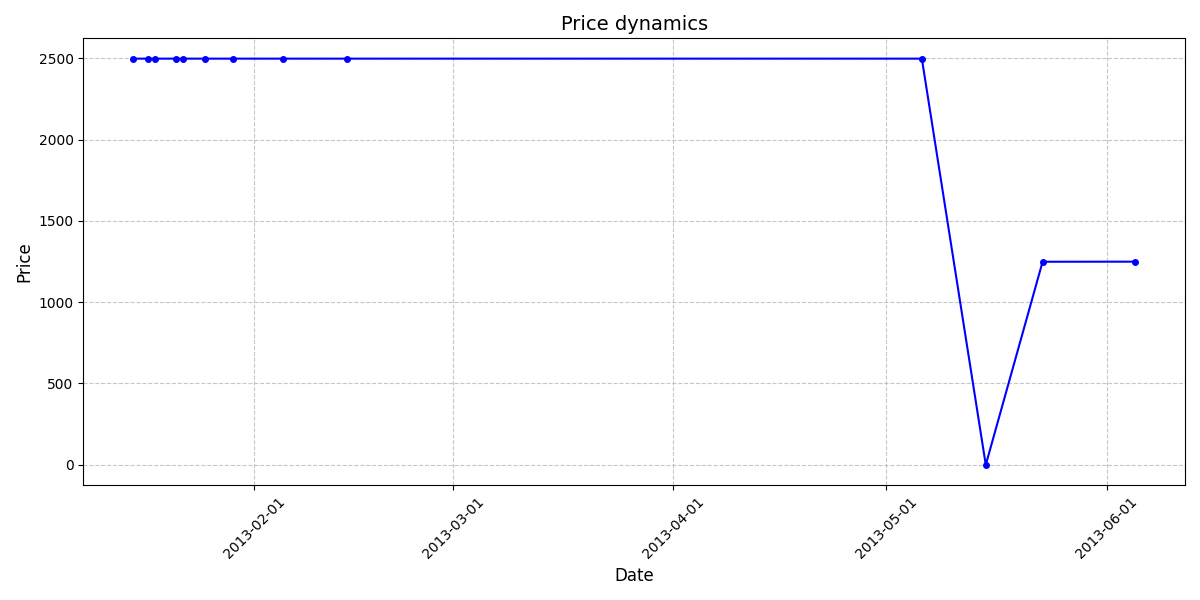

In [52]:
result = df_final[
    (df_final['shop_id'] == 32) & 
    (df_final['item_id'] == 2973)
].sort_values('date')

plt.figure(figsize=(12, 6))
plt.plot(result['date'], result['item_price'], marker='o', linestyle='-', color='b', markersize=4)
plt.title('Price dynamics', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

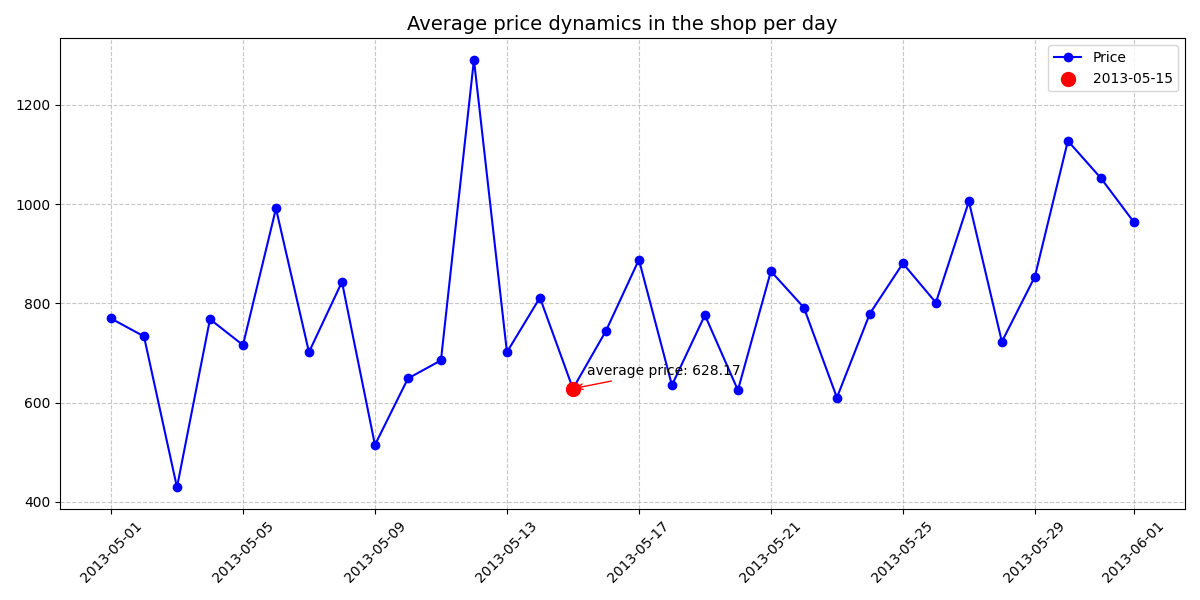

In [53]:
mask = (
    (df_final['shop_id'] == 32) & 
    ((df_final['main_category'] == "Игры") |
      (df_final['main_category'] == "Игры PC")) &
    (df_final['date'] >= '2013-05-01') & 
    (df_final['date'] <= '2013-06-01')
)
result = df_final.loc[mask].groupby('date')['item_price'].mean().reset_index()


plt.figure(figsize=(12, 6))
plt.plot(result['date'], result['item_price'], marker='o', linestyle='-', color='b', label='Price')
target_date = pd.to_datetime('2013-05-15')
price_at_date = result.loc[result['date'] == target_date, 'item_price']

if not price_at_date.empty:
    plt.scatter(target_date, price_at_date.iloc[0], color='red', s=100, zorder=5, label='2013-05-15')
    plt.annotate(f'average price: {price_at_date.iloc[0]:.2f}', 
                 xy=(target_date, price_at_date.iloc[0]), 
                 xytext=(10, 10), 
                 textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='red'))
plt.title('Average price dynamics in the shop per day', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_final.loc[484683, "item_price"] = 1249.0
df_final.loc[484683, "real_price"] = 1249.0 / POPULATION_DATAAAAAAAAAAAAAA[2013, 5]

Item prices trend in the shop suggests that discounts started around the anomalous record. And looking at the average games prices trend for the entire shop shows that the average price was low on that day. This indicates that there were large-scale discounts, so it is most reasonable to use the product price like it was on sale.

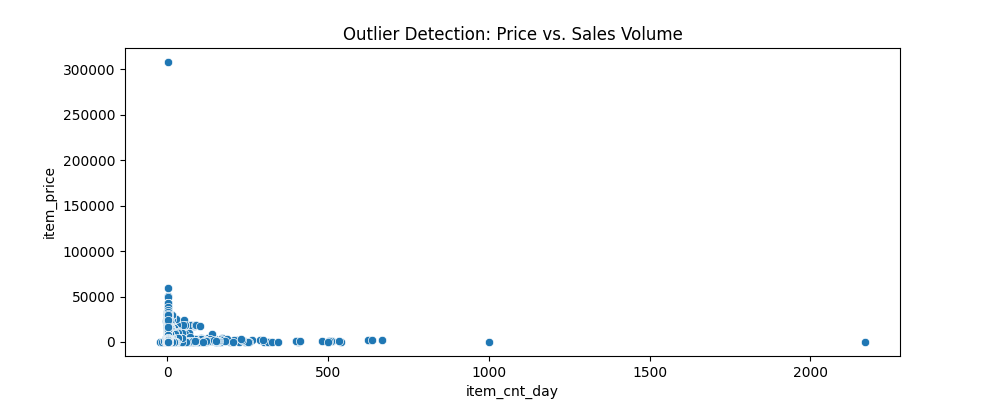

In [56]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x=df_final['item_cnt_day'], y=df_final['item_price'])
plt.title('Outlier Detection: Price vs. Sales Volume')
plt.show()

The plot shows several records that stand out strongly in terms of sales quantity or price.

In [57]:
df_final[df_final["main_category"] != "Программы"].nlargest(50, "item_price").head(50)

,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,item_name,item_category_id,cleaned_name,corrected_item_id,item_category_name,main_category,subcategory,shop_name,city,real_price
961209,2013-09-17,8,12,11365,59200.0,2013,9,17,1,-4.067366e-01,...,Доставка (EMS),9,доставкаems,11365,Доставка товара,Доставка товара,Доставка товара,Интернет-магазин ЧС,Интернет,NaN
1635289,2014-03-20,14,25,13199,50999.0,2014,3,20,3,-7.907757e-01,...,Коллекционные шахматы (Властелин Колец),69,коллекционныешахматывластелинколец,13199,Подарки - Сувениры,Подарки,Сувениры,"Москва ТРК ""Атриум""",Москва,NaN
3140155,2015-10-20,33,3,13403,42990.0,2015,10,20,1,-7.907757e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,"Балашиха ТРК ""Октябрь-Киномир""",Балашиха,NaN
3140524,2015-10-20,33,22,13403,42990.0,2015,10,20,1,-7.907757e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,Москва Магазин С21,Москва,NaN
3146023,2015-10-23,33,42,13403,42990.0,2015,10,23,4,-9.987165e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,"СПб ТК ""Невский Центр""",СПб,NaN
3155966,2015-10-29,33,12,13403,42990.0,2015,10,29,3,-3.943559e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,Интернет-магазин ЧС,Интернет,NaN
3140309,2015-10-20,33,12,13403,41990.0,2015,10,20,1,-7.907757e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,Интернет-магазин ЧС,Интернет,NaN
3141054,2015-10-20,33,38,13403,41990.0,2015,10,20,1,-7.907757e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,"Омск ТЦ ""Мега""",Омск,NaN
3143477,2015-10-22,33,18,13403,41990.0,2015,10,22,3,-9.680771e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,"Красноярск ТЦ ""Июнь""",Красноярск,NaN
3143789,2015-10-22,33,28,13403,40991.0,2015,10,22,3,-9.680771e-01,...,"Комплект ""Microsoft Xbox One 1TB Limited Edit...",16,комплектmicrosoftxboxone1tblimitededitionhalo5...,13403,Игровые консоли - XBOX ONE,Игровые консоли,XBOX ONE,"Москва ТЦ ""МЕГА Теплый Стан"" II",Москва,NaN


In [58]:
df_final.loc[df_final['item_name'] == 'Radmin 3  - 522 лиц.', ['item_name', 'item_price', 'item_cnt_day', 'no_inflation_price']] = ["Radmin 3", 307980.0 / 522, 522, 289183.0985915493 / 522]


It is more reasonable to transform a purchase of one license by 522 people into a purchase of 522 licenses by one customer to maintain consistency in the records.

In [59]:
programs = df_final[df_final['main_category'] == "Программы"]
programs.head(50)

,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,item_name,item_category_id,cleaned_name,corrected_item_id,item_category_name,main_category,subcategory,shop_name,city,real_price
37,2013-01-01,0,7,3007,1790.0,2013,1,1,1,0.201299,...,Dr.Web Security Space КЗ 2 ПК/2 года (картонна...,75,drwebsecurityspaceкз2пк2годакартоннаяупаковка,3007,Программы - Для дома и офиса,Программы,Для дома и офиса,"Воронеж ТРЦ ""Максимир""",Воронеж,NaN
110,2013-01-01,0,8,484,300.0,2013,1,1,1,0.201299,...,1С:Бухгалтерия 8. Учебная версия. Издание 6.,73,1сбухгалтерия8учебнаяверсияиздание6,484,Программы - 1С:Предприятие 8,Программы,1С:Предприятие 8,"Воронеж ТРЦ Сити-Парк ""Град""",Воронеж,NaN
186,2013-01-01,0,14,484,300.0,2013,1,1,1,0.201299,...,1С:Бухгалтерия 8. Учебная версия. Издание 6.,73,1сбухгалтерия8учебнаяверсияиздание6,484,Программы - 1С:Предприятие 8,Программы,1С:Предприятие 8,"Казань ТЦ ""ПаркХаус"" II",Казань,NaN
262,2013-01-01,0,15,3007,1790.0,2013,1,1,1,0.201299,...,Dr.Web Security Space КЗ 2 ПК/2 года (картонна...,75,drwebsecurityspaceкз2пк2годакартоннаяупаковка,3007,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
263,2013-01-01,0,15,3158,1290.0,2013,1,1,1,0.201299,...,ESET NOD32 Антивирус + Bonus + расширенный фун...,75,esetnod32антивирусbonusрасширенныйфункционал3п...,3158,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
277,2013-01-01,0,15,4161,899.0,2013,1,1,1,0.201299,...,Kaspersky Internet Security 2012 Russian Editi...,75,kasperskyinternetsecurity2012russianedition2de...,4161,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
278,2013-01-01,0,15,4211,1990.0,2013,1,1,1,0.201299,...,Kaspersky ONE Russian Edition. 3-Device 1 year...,75,kasperskyonerussianedition3device1yearbasebox,4211,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
296,2013-01-01,0,15,7814,3889.5,2013,1,1,1,0.201299,...,Win Home Basic 7 Russian Russia Only DVD,75,winhomebasic7russianrussiaonlydvd,7814,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
297,2013-01-01,0,15,7820,2290.0,2013,1,1,1,0.201299,...,Win Pro 8 32-bit/64-bit Russian VUP Russia Onl...,75,winpro832bit64bitrussianvuprussiaonlydvd,7820,Программы - Для дома и офиса,Программы,Для дома и офиса,"Калуга ТРЦ ""XXI век""",Калуга,NaN
378,2013-01-01,0,18,4163,1590.0,2013,1,1,1,0.201299,...,Kaspersky Internet Security 2013 Russian Editi...,75,kasperskyinternetsecurity2013russianedition2de...,4163,Программы - Для дома и офиса,Программы,Для дома и офиса,"Красноярск ТЦ ""Июнь""",Красноярск,NaN


Looking at other records from the 'Software' category, it can be seen that licenses for different numbers of devices are often purchased in a single transaction.

Prices in the other large records look reasonable except for the delivery record.

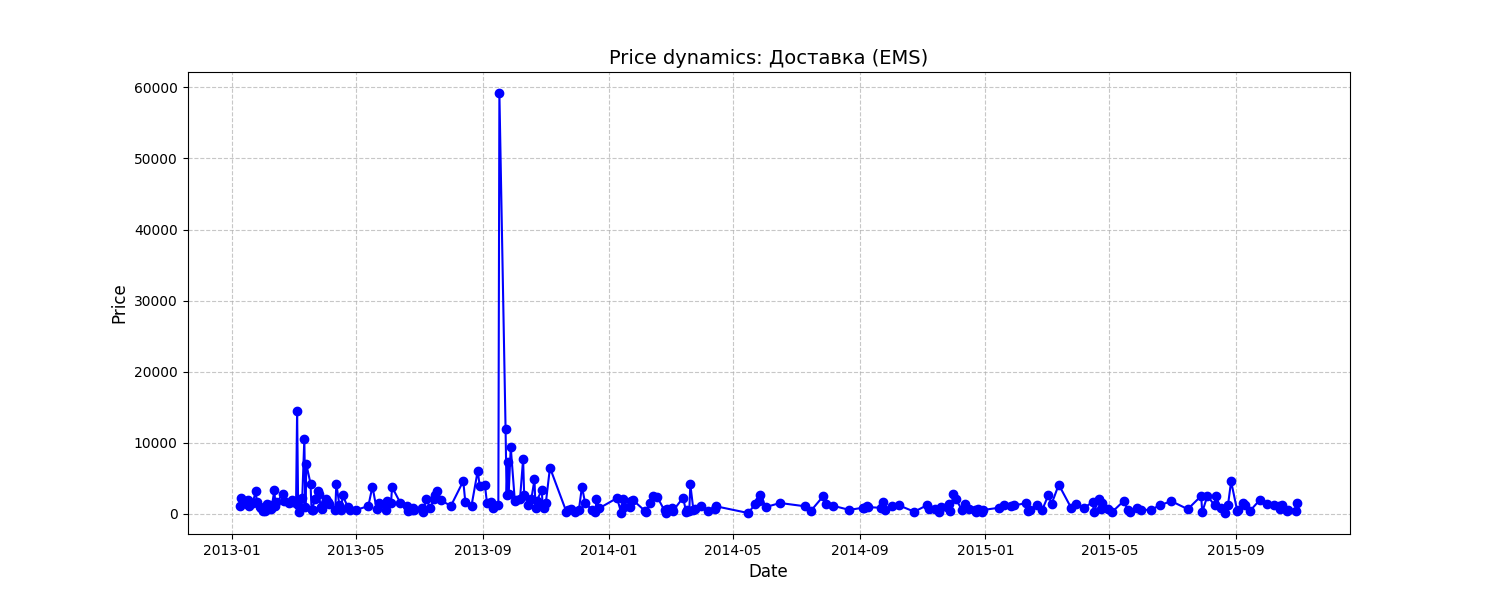

In [60]:
EMS_data = df_final[df_final["item_name"] == "Доставка (EMS)"].copy()
EMS_data['date'] = pd.to_datetime(EMS_data['date'], format='%d.%m.%Y')
daily_sales = EMS_data.groupby('date')['item_price'].sum()
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='b')
plt.title('Price dynamics: Доставка (EMS)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [61]:
indices_to_drop = df_final[df_final["item_name"] == "Доставка (EMS)"].nlargest(1, "item_price").index
df_final = df_final.drop(indices_to_drop)

One point stands out far too strongly from the many other records, so it should be removed.

In [62]:
top_10_cnt = df_final.nlargest(10, "item_cnt_day")
top_10_cnt.head(10)

,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,item_name,item_category_id,cleaned_name,corrected_item_id,item_category_name,main_category,subcategory,shop_name,city,real_price
3154630,2015-10-28,33,12,11373,0.908714,2015,10,28,2,-5.712682e-01,...,Доставка до пункта выдачи (Boxberry),9,доставкадопунктавыдачиboxberry,11373,Доставка товара,Доставка товара,Доставка товара,Интернет-магазин ЧС,Интернет,NaN
2555550,2015-01-15,24,12,20949,4.000000,2015,1,15,3,1.011683e-01,...,Фирменный пакет майка 1С Интерес белый (34*42)...,71,фирменныйпакетмайка1синтересбелый344245мкм,20949,"Подарки - Сумки, Альбомы, Коврики д/мыши",Подарки,"Сумки, Альбомы, Коврики д/мыши",Интернет-магазин ЧС,Интернет,NaN
3103630,2015-09-30,32,12,9248,1692.526158,2015,9,30,2,-1.133108e-15,...,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",80,билетигромир20153октября2015сайтцифроваяверсия,9248,Служебные - Билеты,Служебные,Билеты,Интернет-магазин ЧС,Интернет,NaN
3104540,2015-09-30,32,55,9249,1702.825746,2015,9,30,2,-1.133108e-15,...,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,билетигромир20153октября2015сайтупрцифроваяверсия,9249,Билеты (Цифра),Билеты (Цифра),Билеты (Цифра),Цифровой склад 1С-Онлайн,Интернет,NaN
2778559,2015-04-14,27,12,3731,1904.548077,2015,4,14,1,2.079117e-01,...,"Grand Theft Auto V [PC, русские субтитры]",30,grandtheftautovpcрусскиесубтитры,3731,Игры PC - Стандартные издания,Игры PC,Стандартные издания,Интернет-магазин ЧС,Интернет,NaN
2844405,2015-05-19,28,12,11373,155.192950,2015,5,19,1,-6.513725e-01,...,Доставка до пункта выдачи (Boxberry),9,доставкадопунктавыдачиboxberry,11373,Доставка товара,Доставка товара,Доставка товара,Интернет-магазин ЧС,Интернет,NaN
3103218,2015-09-29,32,55,9249,1500.000000,2015,9,29,1,-2.079117e-01,...,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",8,билетигромир20153октября2015сайтупрцифроваяверсия,9249,Билеты (Цифра),Билеты (Цифра),Билеты (Цифра),Цифровой склад 1С-Онлайн,Интернет,NaN
1256153,2013-12-13,11,12,6066,590.000000,2013,12,13,4,4.853020e-01,...,Radmin 3,75,radmin3522лиц,6066,Программы - Для дома и офиса,Программы,Для дома и офиса,Интернет-магазин ЧС,Интернет,NaN
2188983,2014-10-02,21,12,9242,1500.000000,2014,10,2,3,3.943559e-01,...,"Билет ""ИгроМир 2014"" (на один день (отдельно -...",8,билетигромир2014наодинденьотдельно45октября2014,9242,Билеты (Цифра),Билеты (Цифра),Билеты (Цифра),Интернет-магазин ЧС,Интернет,NaN
2212700,2014-10-09,21,55,19437,899.000000,2014,10,9,3,9.680771e-01,...,"Средиземье: Тени Мордора [PC, Цифровая версия]",31,средиземьетенимордораpcцифроваяверсия,19437,Игры PC - Цифра,Игры PC,Цифра,Цифровой склад 1С-Онлайн,Интернет,NaN


Let us investigate records with a large number of sales using a rolling MAD-score.

In [63]:
def rolling_mad_score(df, target_date):
    start_date = target_date - pd.Timedelta(days=45)
    end_date = target_date + pd.Timedelta(days=45)
    mask = (df["date"] >= start_date) & (df["date"] <= end_date) & (df["date"] != target_date)
    target_val = df[df["date"] == target_date]['item_cnt_day'].iloc[0]
    window_data = df.loc[mask, 'item_cnt_day']
    if window_data.sum() == 0:
        return -1
    median = np.median(window_data)
    mad = np.median(np.abs(window_data - median))
    score = np.abs(target_val - median) / (mad + 1e-6)
    return score

for index, row in top_10_cnt.iterrows():
    vals = df_final[df_final["item_name"] == row["item_name"]].copy()
    print(index, "   ", row["item_name"], "   ", row["item_cnt_day"], "   ",rolling_mad_score(vals, row["date"]))

3154630     Доставка до пункта выдачи (Boxberry)     2169.0     1082.4994587502706
2555550     Фирменный пакет майка 1С Интерес белый (34*42) 45 мкм     1000.0     0.99999950000025
3103630     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) [Цифровая версия]     669.0     132.5999734800053
3104540     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) УПР [Цифровая версия]     637.0     125.99997480000503
2778559     Grand Theft Auto V [PC, русские субтитры]     624.0     22.33332588889137
2844405     Доставка до пункта выдачи (Boxberry)     539.0     88.49998525000245
3103218     Билет "ИгроМир 2015" - 3 октября 2015 (сайт) УПР [Цифровая версия]     533.0     105.1999789600042
1256153     Radmin 3     522.0     -1
2188983     Билет "ИгроМир 2014" (на один день (отдельно - 4, 5 октября 2014))     512.0     0.0
2212700     Средиземье: Тени Мордора [PC, Цифровая версия]     508.0     505.99949400050605


The rolling MAD-score analysis showed that all records except two have extremely large values indicating outliers.

A rolling MAD-score is more appropriate here than, for example, a z-score, because the distribution may vary across different time periods due to factors such as discounts or holidays. Therefore, observations near the anomaly are more important than the entire sample.

In [64]:
df_final.drop([2909818, 2864235, 2851091, 2608040, 2626181, 2851073, 2067669, 2864260], inplace=True)

Let us examine all delivery-related records (Boxberry) in more detail.

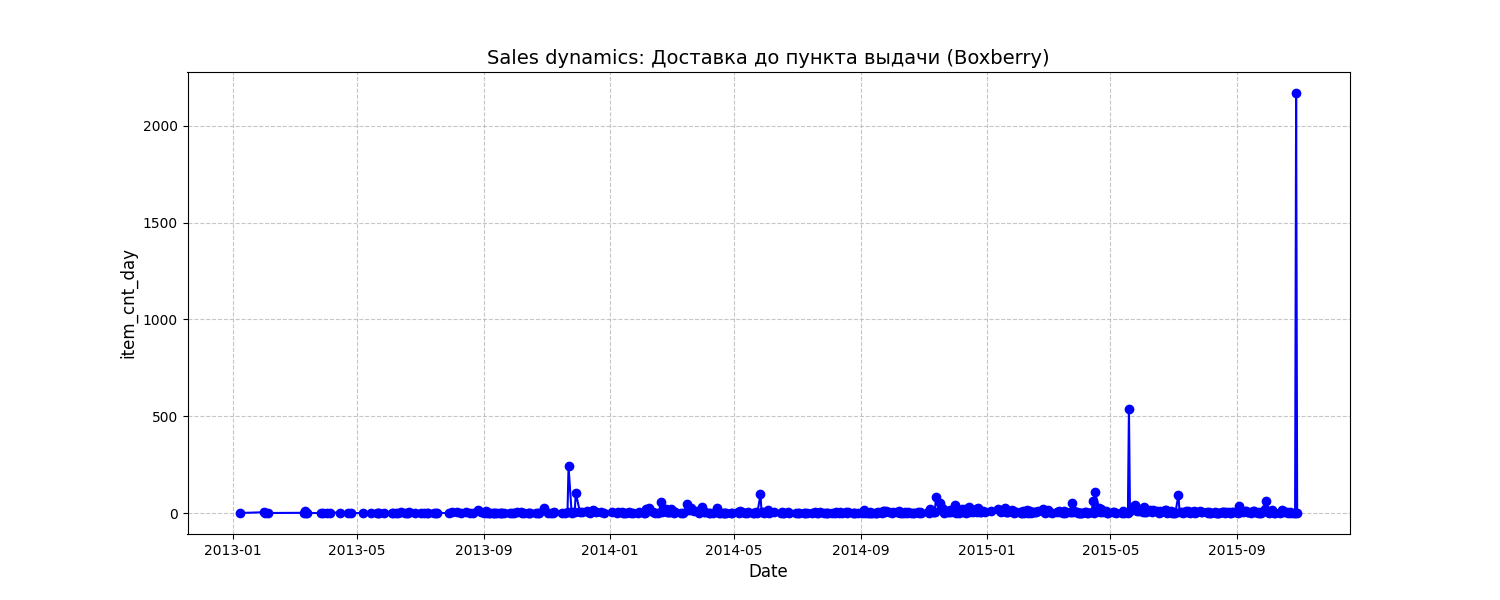

In [65]:
boxberry_data = df_final[df_final["item_name"] == "Доставка до пункта выдачи (Boxberry)"].copy()
boxberry_data['date'] = pd.to_datetime(boxberry_data['date'], format='%d.%m.%Y')
daily_sales = boxberry_data.groupby('date')['item_cnt_day'].sum()
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linestyle='-', color='b')
plt.title('Sales dynamics: Доставка до пункта выдачи (Boxberry)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('item_cnt_day', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [66]:
indices_to_drop = df_final[df_final["item_name"] == "Доставка до пункта выдачи (Boxberry)"].nlargest(2, "item_cnt_day").index
df_final = df_final.drop(indices_to_drop)

For the Boxberry delivery service, two records were found that differ significantly from the overall data structure.

Against the background of many small values, these points appear anomalous and may worsen model training.

# Exploratory Data Analysis

In [67]:
def plot_total_sales(period):
    plt.close("all")
    plt.figure(figsize=(15, 5))

    if period == "By months (date_block_num)":
        group_col = "date_block_num"
        x_label = "Month (date_block_num)"
        title = "Average Daily Sales by Month"
        mapping_dict = NUMBER_OF_DAYS_IN_MONTH
        is_string_key = True

    elif period == "By days of week":
        group_col = "week_day"
        x_label = "Day of the week"
        title = "Average Daily Sales by Day of Week"
        mapping_dict = NUMBER_OF_DAYS_OF_WEEK
        is_string_key = False

    elif period == "By days of month":
        group_col = "month_day"
        x_label = "Day of the month"
        title = "Average Daily Sales by Day of Month"
        mapping_dict = NUMBER_OF_DAYS_OF_MONTH
        is_string_key = False

    agg_data = (
        df_final.groupby(group_col)["item_cnt_day"]
        .sum()
        .reset_index(name="total_sales")
    )

    if is_string_key:
        days_count = agg_data[group_col].astype(str).map(mapping_dict)
    else:
        days_count = agg_data[group_col].map(mapping_dict)

    agg_data["normalized_sales"] = agg_data["total_sales"] / days_count

    sns.lineplot(
        data=agg_data,
        x=group_col,
        y="normalized_sales",
        marker="o",
        color="b",
        label="Average daily sales",
    )

    # Настройка осей
    if period == "By months (date_block_num)":
        plt.xlim(df_final["date_block_num"].min(),
                 df_final["date_block_num"].max())

    elif period == "By days of week":
        if agg_data[group_col].min() == 0:
            plt.xticks(
                range(7),
                ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(0, 6)
        else:
            plt.xticks(
                range(1, 8),
                ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(1, 7)

    elif period == "By days of month":
        plt.xticks(range(1, 32))
        plt.xlim(1, 31)

    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Average items sold per day", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()


interact(
    plot_total_sales,
    period=widgets.Dropdown(
        options=[
            "By months (date_block_num)",
            "By days of week",
            "By days of month",
        ],
        value="By months (date_block_num)",
        description="Timeframe:",
    ),
)

interactive(children=(Dropdown(description='Timeframe:', options=('By months (date_block_num)', 'By days of we…

<function __main__.plot_total_sales(period)>

For datet_block_num graphic: 

The monthly sales chart clearly shows seasonality.

The largest growth is observed in December, which is associated with:

- New Year holidays;
- seasonal promotions.

The overall sales trend also declines over time. This may be related both to some stores abandoning the software and to the fact that much of the dataset consists of electronic products, while consumers increasingly move online and no longer need to buy physical products in stores.

For day of the month graphic:

Certain patterns can be observed within a month.

Sales decrease around the middle of the month, and there are fewer records in the last days because of data collection specifics.

This indicates the presence of intra-month seasonality.

For day of the week graphic:

The chart shows that people buy more on weekends, especially on Saturdays, and that sales tend to increase throughout the week.

In [68]:
def plot_autocorrelation(period):

    plt.close("all")
    fig, ax = plt.subplots(figsize=(16, 6))

    if period == "Monthly (33 lags)":
        sales = (
            df_final.groupby(df_final["date"].dt.to_period("M"))["item_cnt_day"]
            .sum()
        )
        lags = 33
        title = "Autocorrelation of Total Monthly Sales"
        xlabel = "Lag (month)"

    elif period == "Weekly (147 lags)":
        sales = (
            df_final.groupby(df_final["date"].dt.to_period("W"))["item_cnt_day"]
            .sum()
        )
        lags = 147
        title = "Autocorrelation of Total Weekly Sales"
        xlabel = "Lag (week)"

    elif period == "Weekly (20 lags)":
        sales = (
            df_final.groupby(df_final["date"].dt.to_period("W"))["item_cnt_day"]
            .sum()
        )
        lags = 20
        title = "Autocorrelation of Total Weekly Sales"
        xlabel = "Lag (week)"

    plot_acf(sales, lags=lags, ax=ax)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Correlation Coefficient", fontsize=12)
    ax.grid(True)

    plt.show()


interact(
    plot_autocorrelation,
    period=widgets.Dropdown(
        options=[
            "Monthly (33 lags)",
            "Weekly (147 lags)",
            "Weekly (20 lags)",
        ],
        value="Monthly (33 lags)",
        description="Period:",
    ),
)

interactive(children=(Dropdown(description='Period:', options=('Monthly (33 lags)', 'Weekly (147 lags)', 'Week…

<function __main__.plot_autocorrelation(period)>

For month graphic: The previous two months have a strong influence, while the relationship becomes much weaker beyond that period.

For full weeks graphic: No clear seasonal patterns are visible in the plot.

For small week graphic: After refining the analysis, it becomes clear that the relationship remains fairly strong for about 8 weeks and then gradually declines.

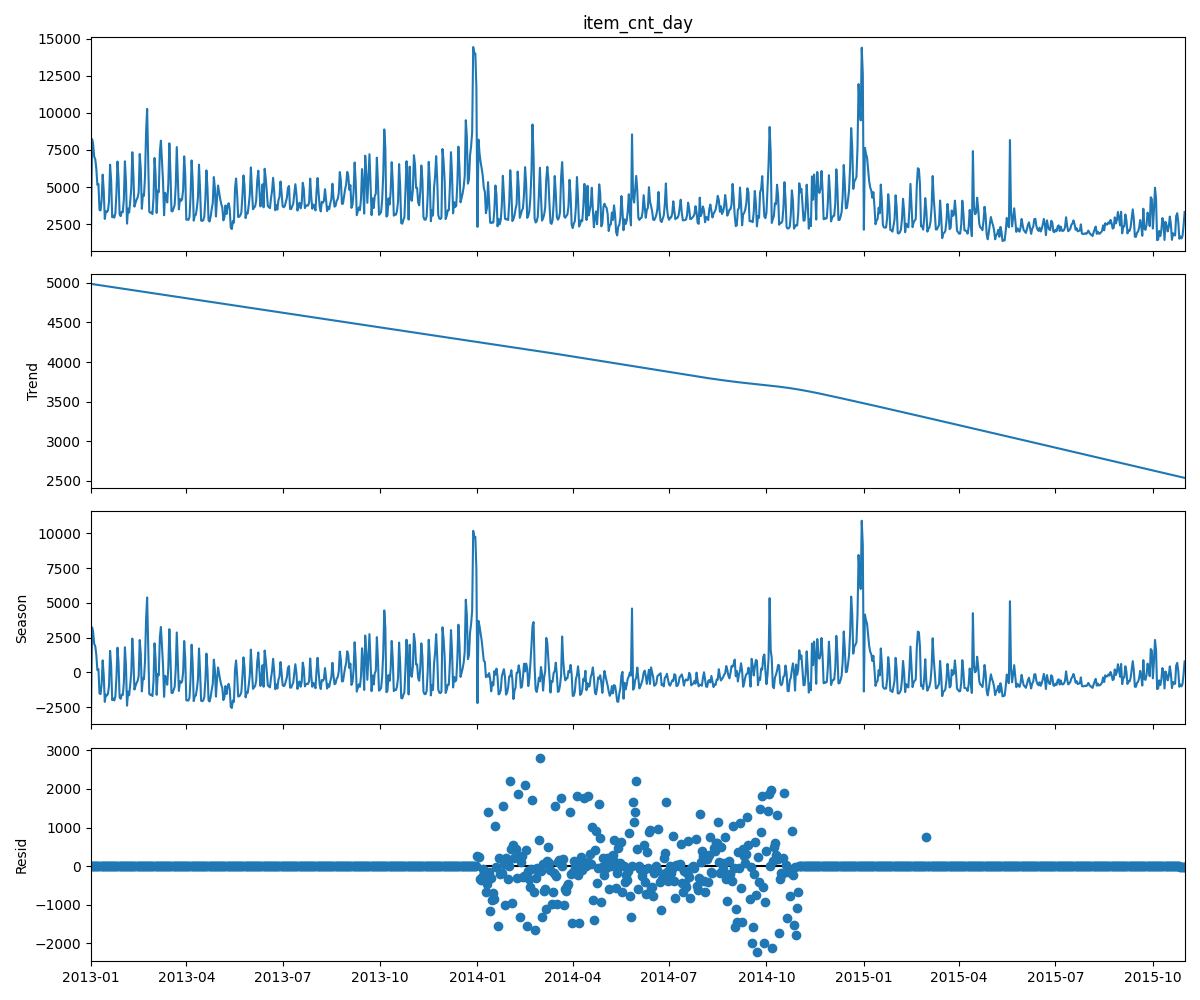

In [69]:
daily_sales = df_final.groupby('date')['item_cnt_day'].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)
daily_sales = daily_sales.asfreq('D').fillna(0)
stl = STL(daily_sales, period=365, robust=True)
result = stl.fit()
fig = result.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

The decomposition clearly reveals a downward trend and annual seasonality, but the residual noise looks unusual, which may be related to the unstable nature of the dataset.

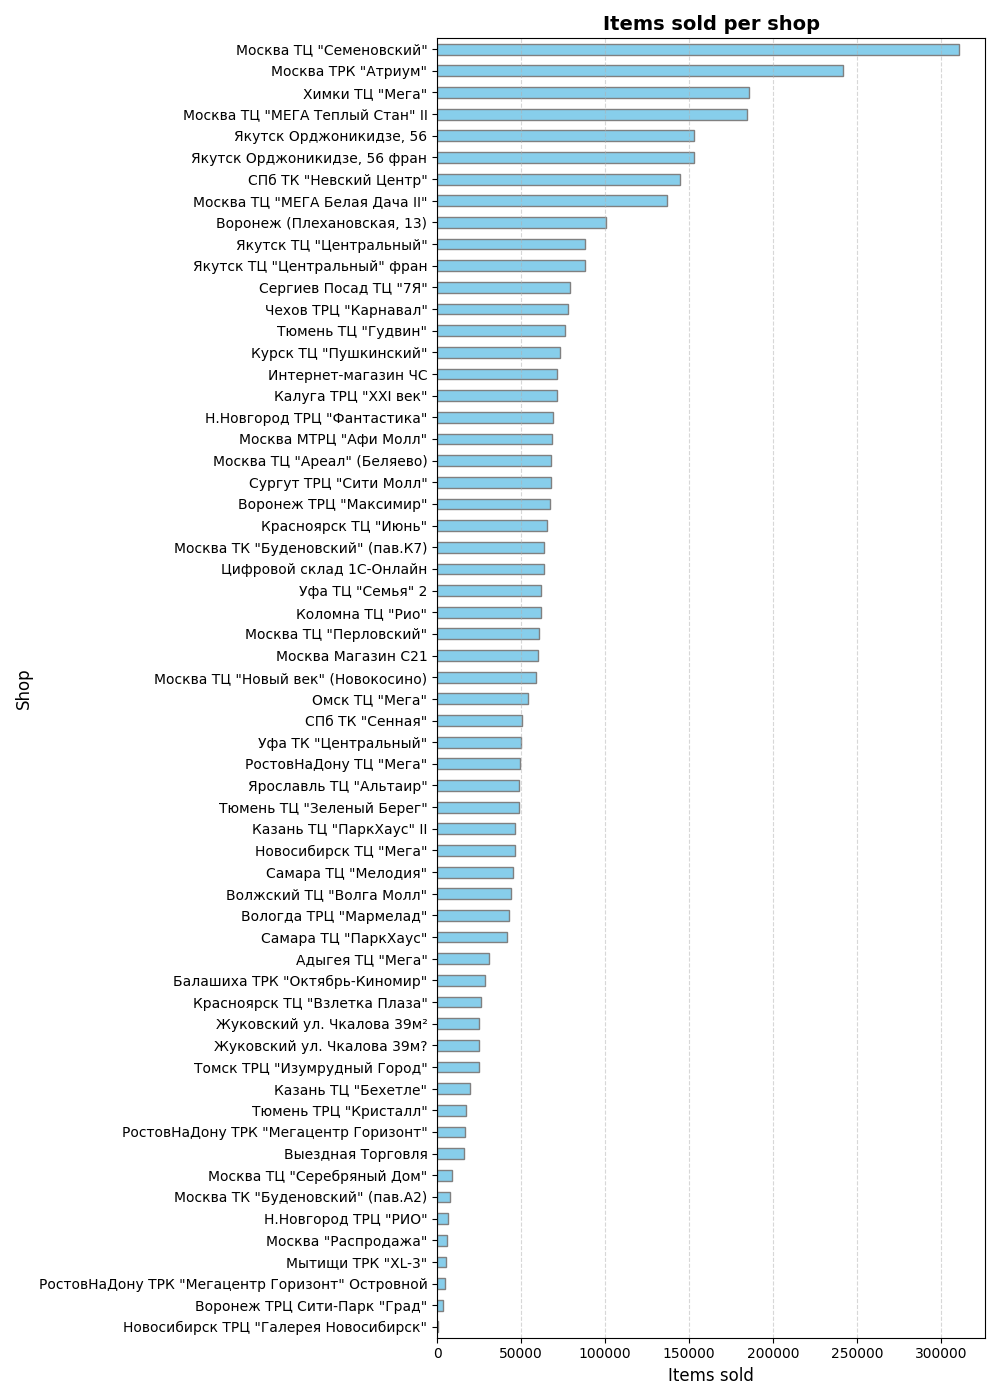

In [70]:
shop_sales = df_final.groupby("shop_name")["item_cnt_day"].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 14))
shop_sales.plot(kind='barh', color='skyblue', edgecolor='gray')
plt.title('Items sold per shop', fontsize=14, fontweight='bold')
plt.xlabel('Items sold', fontsize=12)
plt.ylabel('Shop', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Sales are distributed very unevenly across shops.

Some shops sell several times more products than others.
This may be related to:

- shop size;
- location;
- popularity;
- city size.

Therefore, shop-related features are highly important.

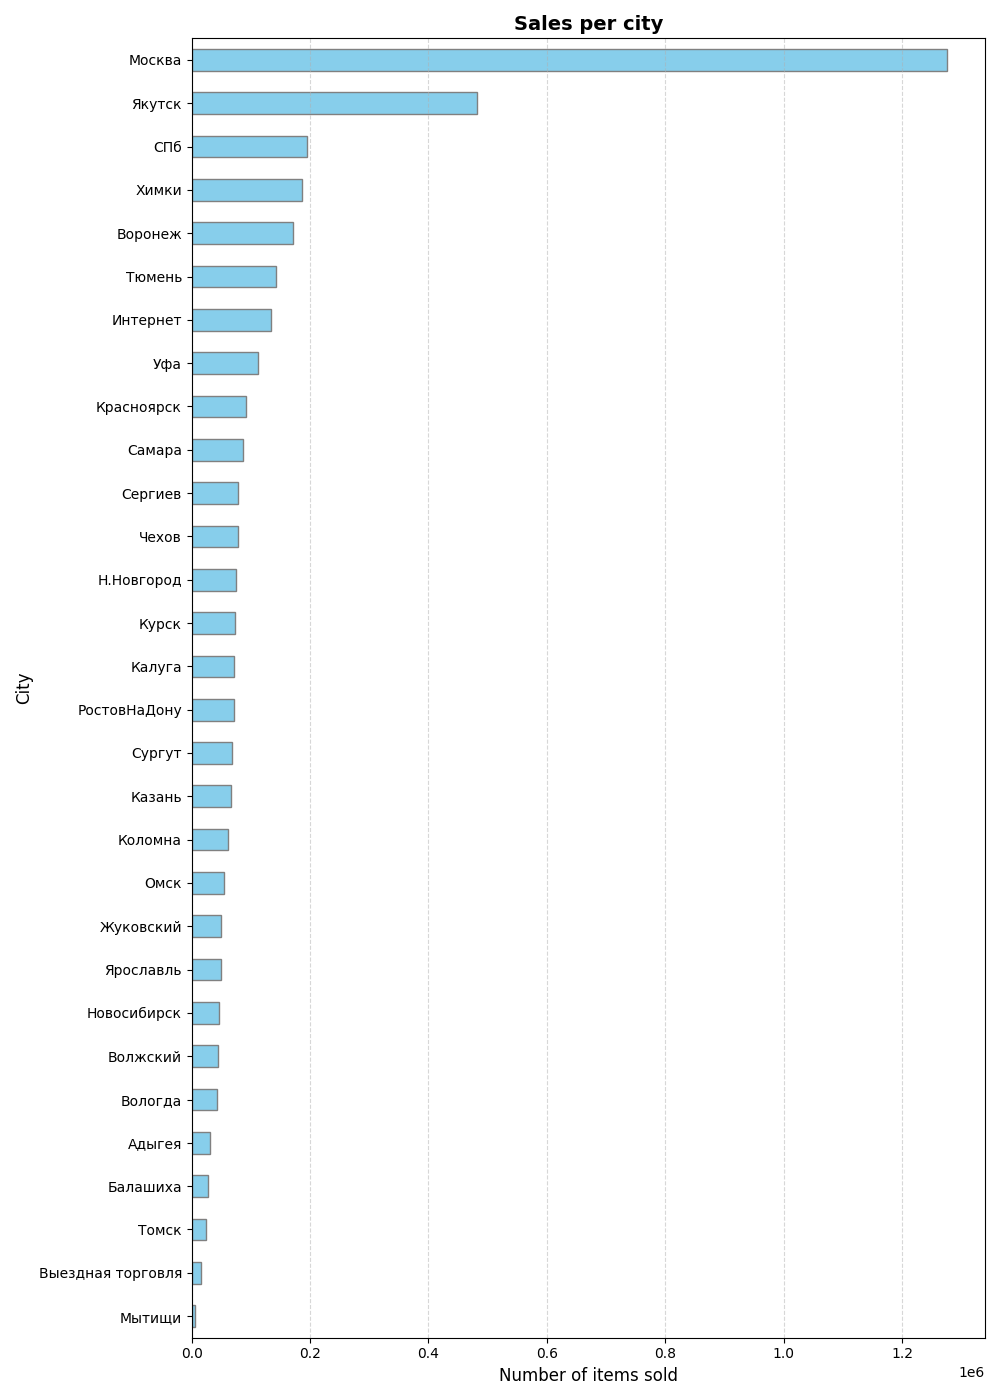

In [ ]:
shop_sales = df_final.groupby("city")["item_cnt_day"].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 14))
shop_sales.plot(kind='barh', color='skyblue', edgecolor='gray')
plt.title('Sales per city', fontsize=14, fontweight='bold')
plt.xlabel('Number of items sold', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

As expected, the largest cities demonstrate significantly higher sales volumes.

This means that geographic information can be useful as a feature for the task.

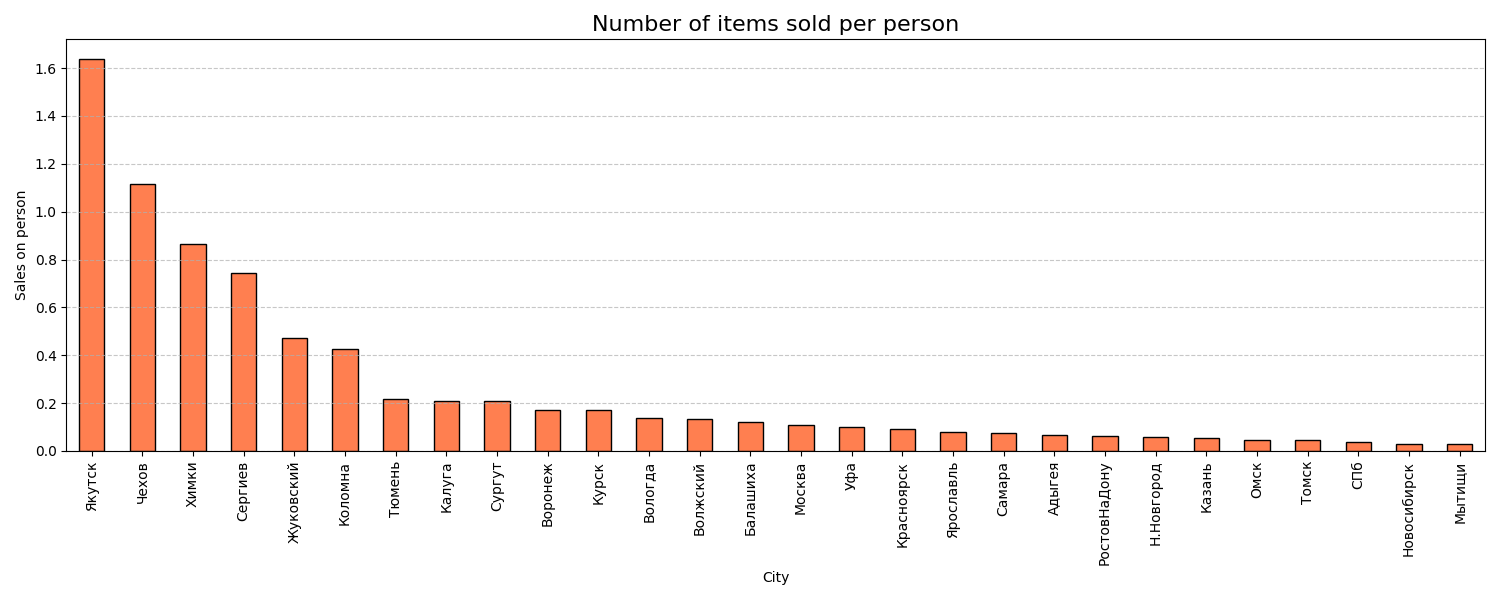

In [74]:
city_sales = df_final[(df_final["city"] != 'Интернет') & (df_final["city"] != 'Выездная торговля')].groupby('city')['item_cnt_day'].sum()

df_pop = pd.DataFrame.from_dict(POPULATION_DATA, orient='index', columns=['population'])
df_metrics = pd.concat([city_sales, df_pop], axis=1).dropna()

df_metrics['sales_per_capita'] = df_metrics['item_cnt_day'] / df_metrics['population']
df_metrics = df_metrics.sort_values('sales_per_capita', ascending=False)

plt.figure(figsize=(15, 6))
df_metrics['sales_per_capita'].plot(kind='bar', color='coral', edgecolor='black')

plt.title('Number of items sold per person', fontsize=16)
plt.ylabel('Sales on person')
plt.xlabel('City')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Population data from the 2010 census were used.

The plot shows that customer activity is higher in small and medium-sized cities.

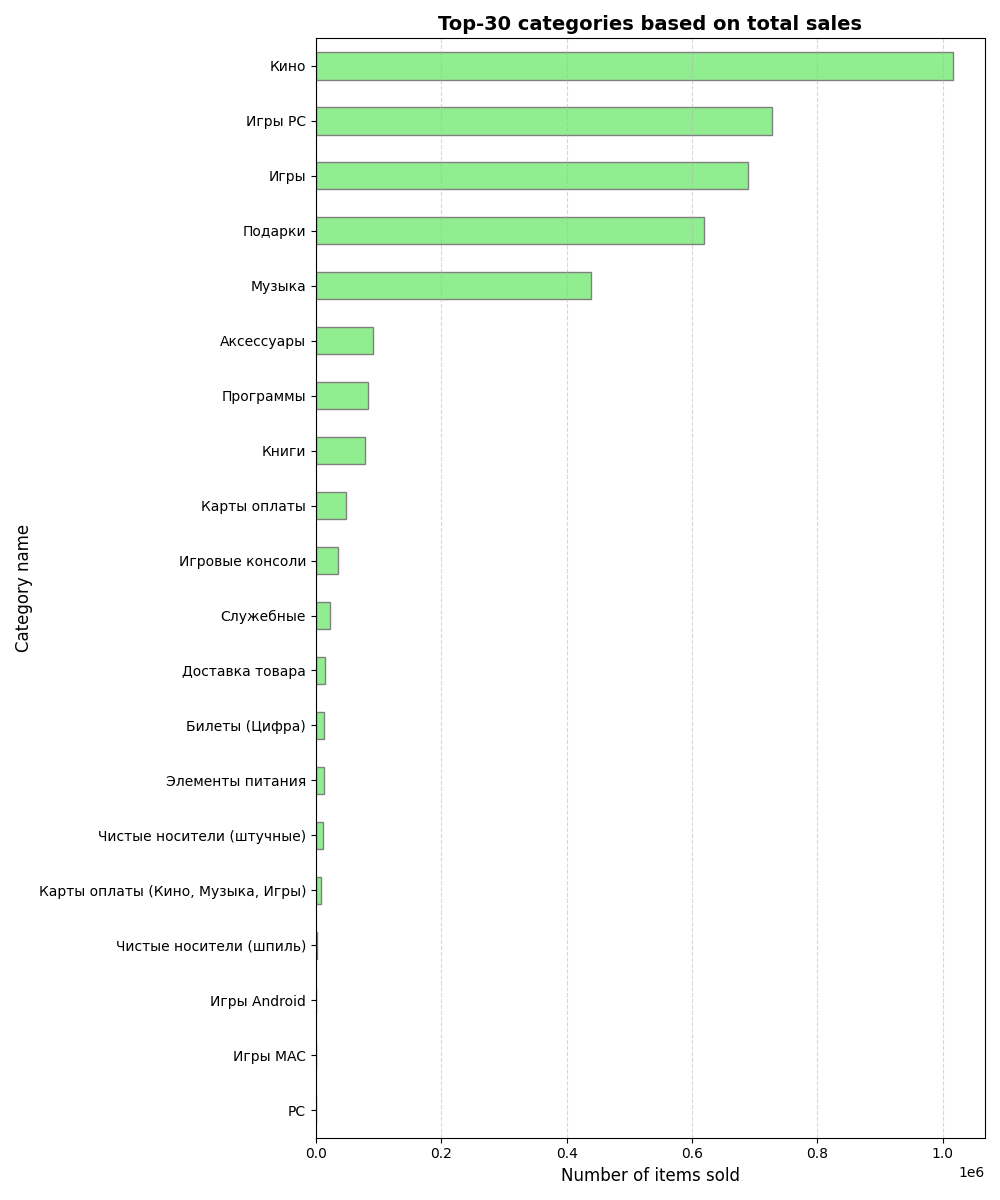

In [91]:
top_categories = df_final.groupby("main_category")["item_cnt_day"].sum().sort_values(ascending=True).tail(30)
plt.figure(figsize=(10, 12))
top_categories.plot(kind='barh', color='lightgreen', edgecolor='gray')
plt.title('Top-30 categories based on total sales', fontsize=14, fontweight='bold')
plt.xlabel('Number of items sold', fontsize=12)
plt.ylabel('Category name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

The most popular product categories are game discs and movie discs.

In [76]:
valid_categories_df = df_final
category_names = valid_categories_df["item_category_name"].unique()

def plot_single_category(category, period):
    plt.close("all")

    plt.figure(figsize=(15, 5))

    category_data = valid_categories_df[
        valid_categories_df["item_category_name"] == category
    ]

    if period == "By months (date_block_num)":
        group_col = "date_block_num"
        x_label = "Month (date_block_num)"
        title = f"Daily Average Sales Dynamics by Month: {category}"
        mapping_dict = NUMBER_OF_DAYS_IN_MONTH
        is_string_key = True

    elif period == "By days of week":
        group_col = "week_day"
        x_label = "Day of the week"
        title = f"Daily Average Sales Dynamics by Day of Week: {category}"
        mapping_dict = NUMBER_OF_DAYS_OF_WEEK
        is_string_key = False

    elif period == "By days of month":
        group_col = "month_day"
        x_label = "Day of the month"
        title = f"Daily Average Sales Dynamics by Day of Month: {category}"
        mapping_dict = number_of_month_days = NUMBER_OF_DAYS_OF_MONTH
        is_string_key = False

    agg_data = (
        category_data.groupby(group_col)["item_cnt_day"].sum().reset_index()
    )
    agg_data.rename(columns={"item_cnt_day": "total_sales"}, inplace=True)

    if is_string_key:
        days_count = agg_data[group_col].astype(str).map(mapping_dict)
    else:
        days_count = agg_data[group_col].map(mapping_dict)

    agg_data["normalized_sales"] = agg_data["total_sales"] / days_count

    sns.lineplot(
        data=agg_data,
        x=group_col,
        y="normalized_sales",
        marker="o",
        color="b",
        label="Average daily sales",
    )

    if period == "By months (date_block_num)":
        plt.xlim(
            valid_categories_df["date_block_num"].min(),
            valid_categories_df["date_block_num"].max(),
        )
    elif period == "By days of week":
        if agg_data[group_col].min() == 0:
            plt.xticks(
                range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(0, 6)
        else:
            plt.xticks(
                range(1, 8), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
            )
            plt.xlim(1, 7)
    elif period == "By days of month":
        plt.xticks(range(1, 32))
        plt.xlim(1, 31)

    plt.title(title, fontsize=14)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Average items sold per day", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(loc="best")
    plt.show()

interact(
    plot_single_category,
    category=category_names,
    period=widgets.Dropdown(
        options=[
            "By months (date_block_num)",
            "By days of week",
            "By days of month",
        ],
        value="By months (date_block_num)",
        description="Timeframe:",
    ),
)

interactive(children=(Dropdown(description='category', options=('Подарки - Развитие', 'Игры - XBOX 360', 'Игры…

<function __main__.plot_single_category(category, period)>

Graphics of sales for most of the categories are similar to graphics of all of the sales. 

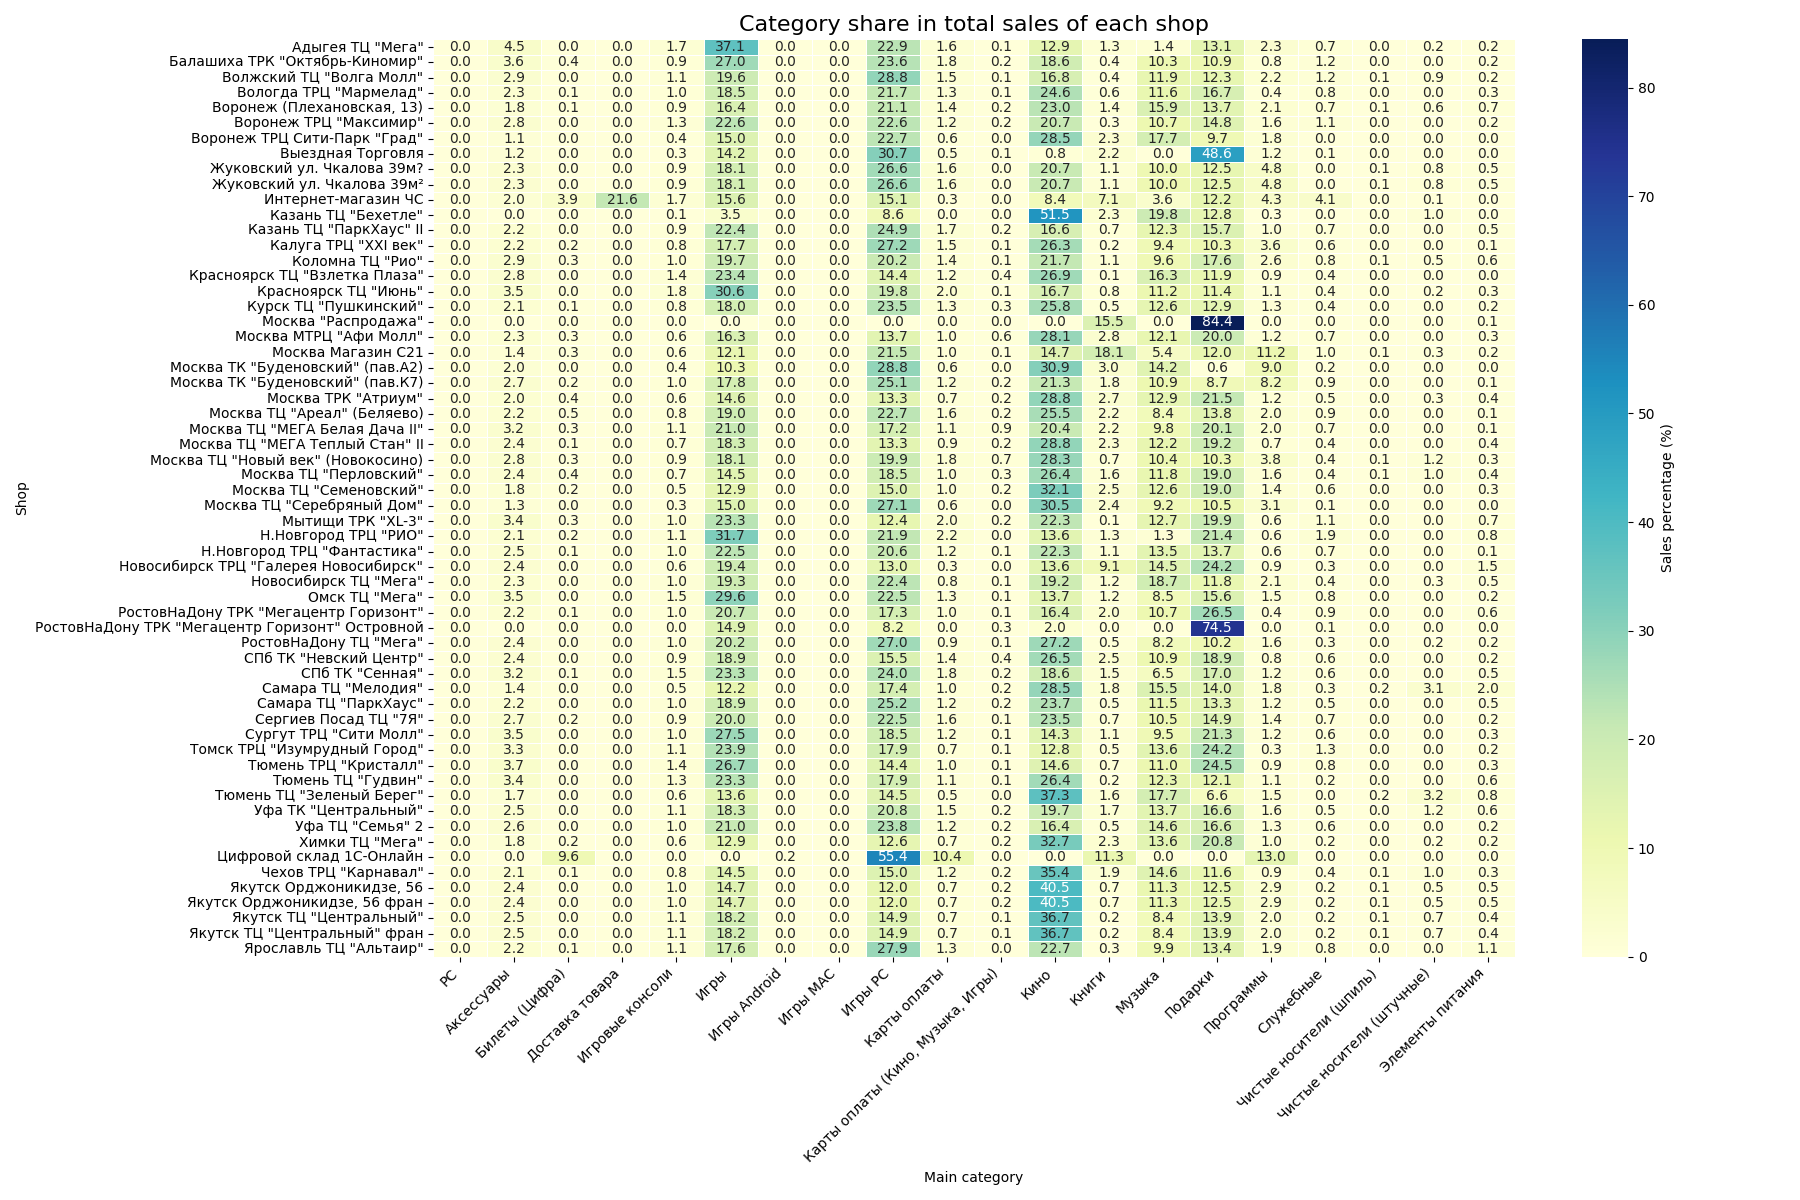

In [77]:
shop_speciality_sales = (
    df_final.groupby(['shop_name', 'main_category'])['item_cnt_day']
    .sum()
    .reset_index()
)


shop_total = (
    df_final.groupby('shop_name')['item_cnt_day']
    .sum()
    .rename('total_sales')
)


shop_speciality_sales = shop_speciality_sales.merge(shop_total, on='shop_name')
shop_speciality_sales['percentage'] = (
    shop_speciality_sales['item_cnt_day'] / shop_speciality_sales['total_sales'] * 100
)


pivot_df = (
    shop_speciality_sales
    .pivot(index='shop_name', columns='main_category', values='percentage')
    .fillna(0)
)


plt.figure(figsize=(18, 12))

sns.heatmap(
    pivot_df,
    cmap='YlGnBu',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Sales percentage (%)'}
)

plt.title('Category share in total sales of each shop', fontsize=16)
plt.xlabel('Main category')
plt.ylabel('Shop')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

For every shop, it is possible to identify 2–3 main product categories.

In [78]:
shop_speciality_sales = (
    df_final.groupby(['shop_name', 'main_category'])['item_cnt_day']
    .sum()
    .reset_index()
)
shop_speciality_sales = shop_speciality_sales.sort_values(['shop_name', 'item_cnt_day'], ascending=[True, False])
shop_speciality_sales['rank'] = shop_speciality_sales.groupby('shop_name').cumcount() + 1
top_3_categories = shop_speciality_sales[shop_speciality_sales['rank'] <= 3]
shop_specs = (
    top_3_categories.pivot(index='shop_name', columns='rank', values='main_category')
    .rename(columns={1: 'shop_speciality_1', 2: 'shop_speciality_2', 3: 'shop_speciality_3'})
    .fillna('Нет')
)
df_final = df_final.merge(shop_specs, on='shop_name', how='left')
print(df_final[['shop_name', 'shop_speciality_1', 'shop_speciality_2', 'shop_speciality_3']].head(10))

          shop_name shop_speciality_1 shop_speciality_2 shop_speciality_3
0  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
1  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
2  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
3  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
4  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
5  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
6  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
7  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
8  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки
9  Адыгея ТЦ "Мега"              Игры           Игры PC           Подарки


There are too mane categories we could combine similar ones into groups to reduce the number of categories.

In [80]:
df_final['cluster'] = df_final['item_category_name'].map(CLUSTERS_OF_ITEMS)

c:\Users\user\predict-future-sales\.venv\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log1p
  result = func(self.values, **kwargs)


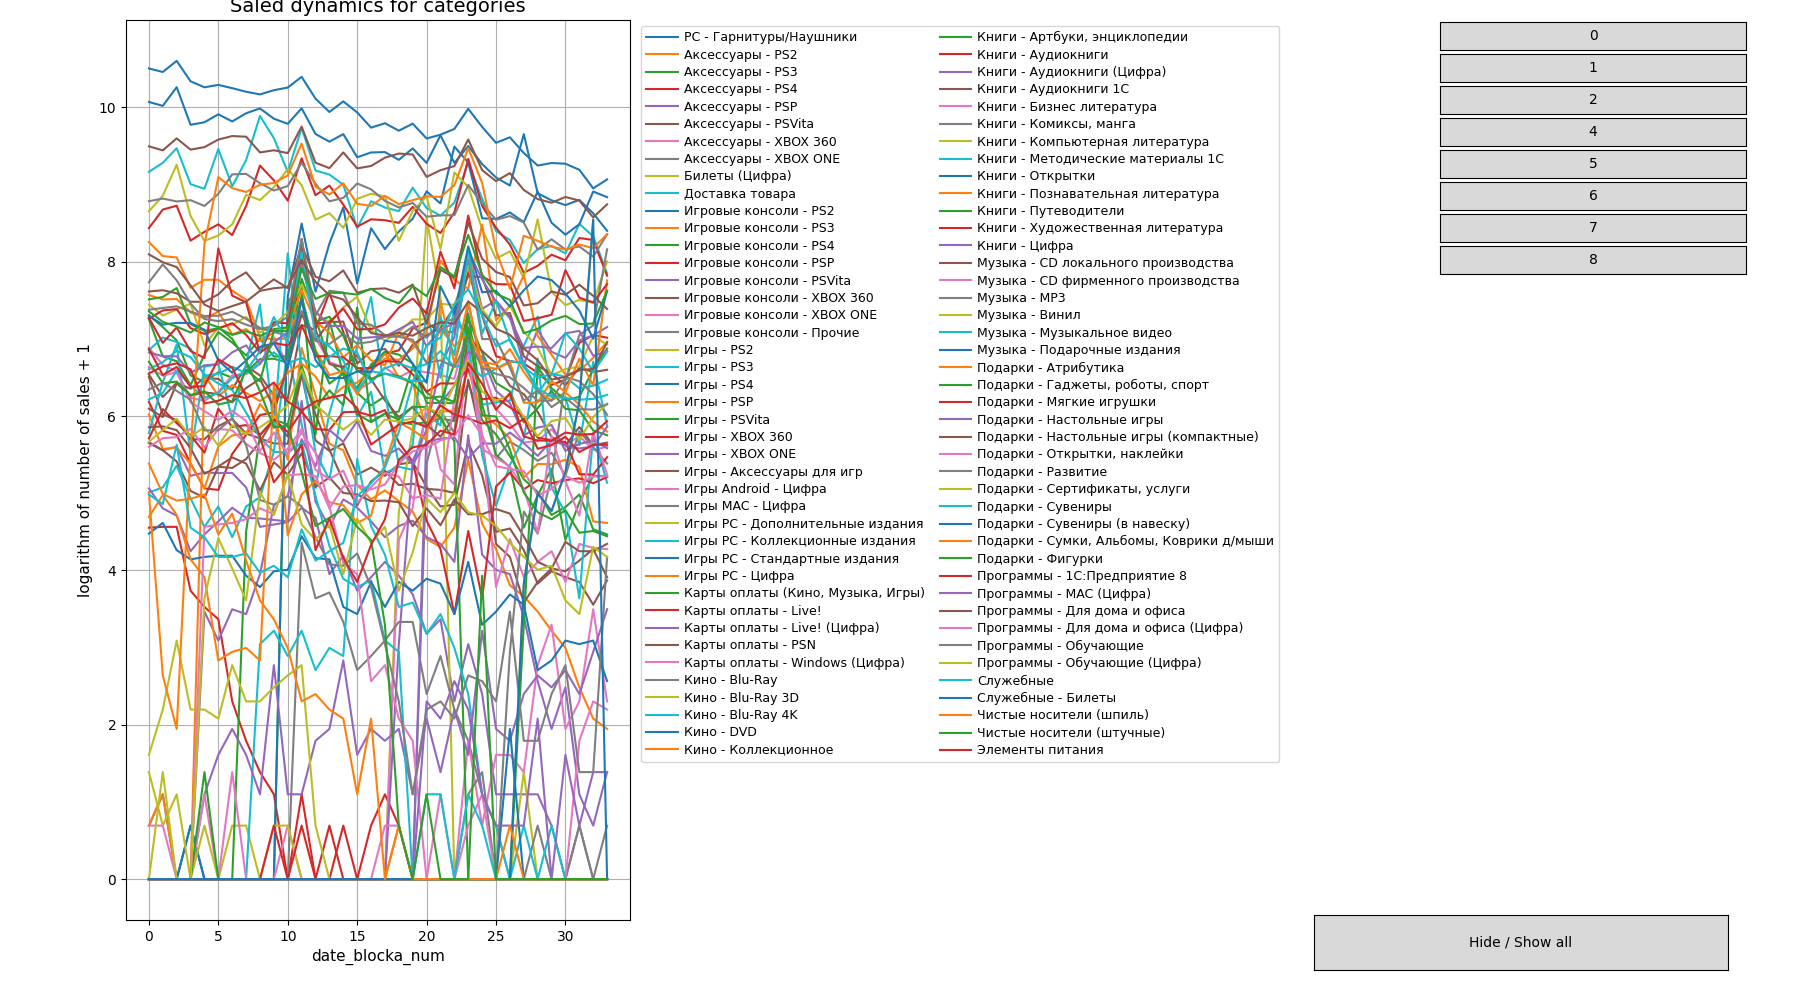

In [81]:
monthly_cat = (
    df_final.groupby(["date_block_num", "item_category_name"])["item_cnt_day"]
    .sum()
    .unstack(fill_value=0)
)

monthly_cat = np.log1p(monthly_cat)


cat_to_clust = (
    df_final[["item_category_name", "cluster"]]
    .drop_duplicates()
    .set_index("item_category_name")["cluster"]
    .to_dict()
)


clusters_to_cats = {}
for cat, main in cat_to_clust.items():
    clusters_to_cats.setdefault(main, []).append(cat)


fig, ax = plt.subplots(figsize=(18, 10))

plt.subplots_adjust(
    left=0.07,
    right=0.35,
    bottom=0.08,
    top=0.98
)

lines = []
line_by_category = {}

for column in monthly_cat.columns:
    line, = ax.plot(
        monthly_cat.index,
        monthly_cat[column],
        linewidth=1.5,
        label=column
    )
    lines.append(line)
    line_by_category[column] = line


leg = ax.legend(
    bbox_to_anchor=(1.01, 1.0),
    loc="upper left",
    ncol=2,
    fontsize=9,
    handlelength=2.5,
    handletextpad=0.5,
    labelspacing=0.35,
    columnspacing=1.2,
    borderpad=0.4,
    frameon=True
)

lined = {}

for legline, legtext, origline in zip(
    leg.get_lines(),
    leg.get_texts(),
    lines
):
    legline.set_picker(True)
    legline.set_pickradius(5)

    legtext.set_picker(True)

    lined[legline] = origline
    lined[legtext] = origline


def update_legend():
    for legline, legtext, origline in zip(
        leg.get_lines(),
        leg.get_texts(),
        lines
    ):
        alpha = 1 if origline.get_visible() else 0.2
        legline.set_alpha(alpha)
        legtext.set_alpha(alpha)

    fig.canvas.draw_idle()


def onpick(event):
    artist = event.artist

    if artist not in lined:
        return

    line = lined[artist]
    line.set_visible(not line.get_visible())

    update_legend()


fig.canvas.mpl_connect("pick_event", onpick)


ax_btn = plt.axes([0.73, 0.03, 0.23, 0.055])
btn = Button(ax_btn, "Hide / Show all")


def toggle_all(event):
    show = not any(line.get_visible() for line in lines)

    for line in lines:
        line.set_visible(show)

    update_legend()


btn.on_clicked(toggle_all)

button_x = 0.8
button_width = 0.17

button_height = 0.028
gap = 0.004

main_buttons = {}
main_visible = {}

clusters_of_categories = sorted(clusters_to_cats.keys())

start_y = 0.95

for i, main in enumerate(clusters_of_categories):

    y = start_y - i * (button_height + gap)

    if y < 0.08:
        break

    ax_button = plt.axes([button_x, y, button_width, button_height])

    b = Button(ax_button, str(main))

    main_buttons[main] = b
    main_visible[main] = True

    def make_callback(cluster):
        def callback(event):

            new_state = not main_visible[cluster]
            main_visible[cluster] = new_state

            for cat in clusters_to_cats[cluster]:
                if cat in line_by_category:
                    line_by_category[cat].set_visible(new_state)

            if new_state:
                ax_button.set_facecolor("0.85")
            else:
                ax_button.set_facecolor("0.65")

            update_legend()

        return callback

    b.on_clicked(make_callback(main))

ax.set_title("Saled dynamics for categories", fontsize=14)
ax.set_xlabel("date_blocka_num", fontsize=11)
ax.set_ylabel("logarithm of number of sales + 1", fontsize=11)

ax.tick_params(axis="both", labelsize=10)
ax.grid(True)

plt.show()

Categories were combined based on how simmilar their graphics of sales dynamics looked.

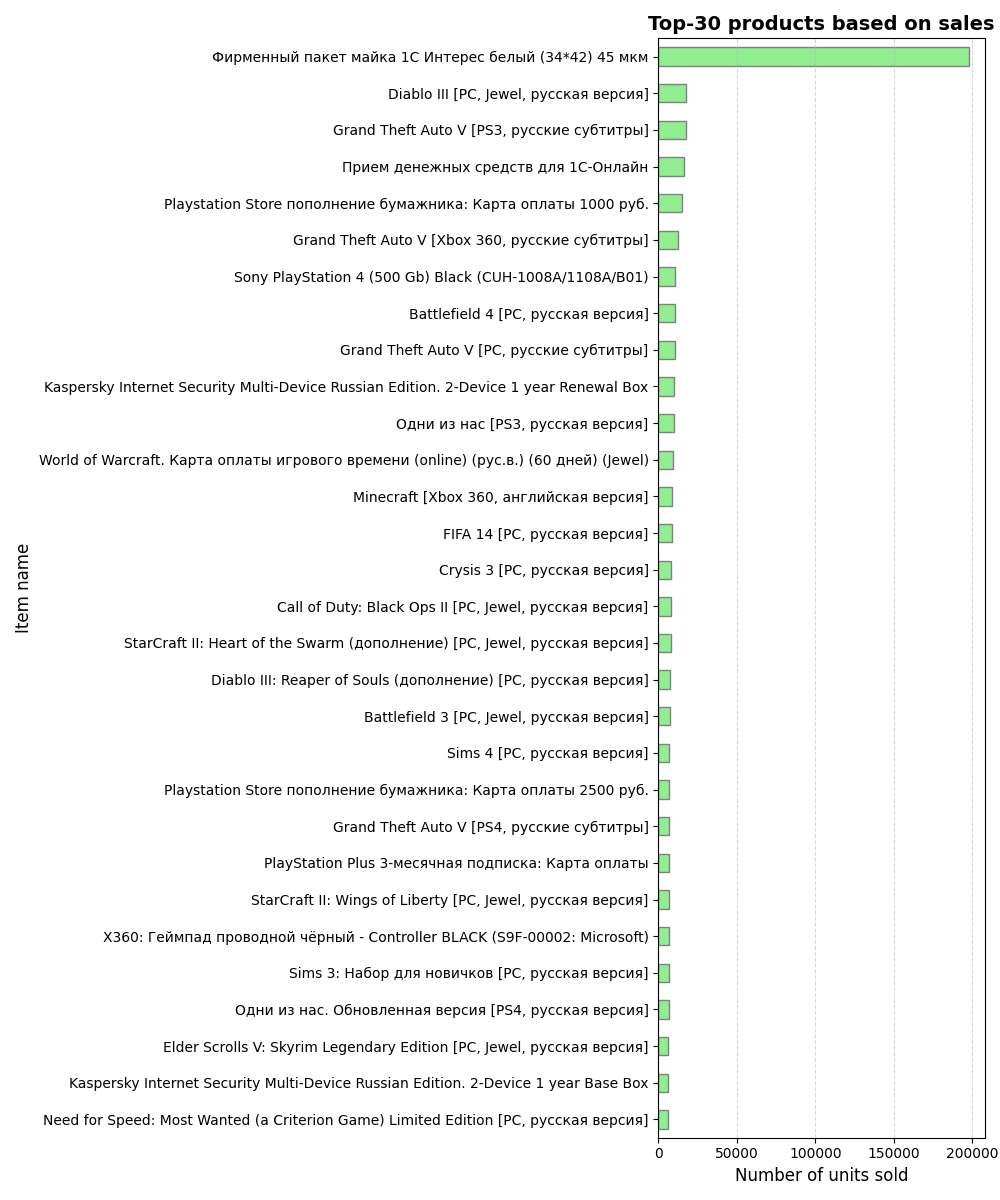

In [82]:
top_items = df_final.groupby("item_name")["item_cnt_day"].sum().sort_values(ascending=True).tail(30)
plt.figure(figsize=(10, 12))
top_items.plot(kind='barh', color='lightgreen', edgecolor='gray')
plt.title('Top-30 products based on sales', fontsize=14, fontweight='bold')
plt.xlabel('Number of units sold', fontsize=12)
plt.ylabel('Item name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

The best-selling products include various bundles.

Some of these products are likely sold together with other items on a regular basis.

Most of the remaining products are games and software.

Features other than those related to date are only weakly correlated.

In [83]:
unique_pairs = train[['shop_id', 'item_id']].drop_duplicates().shape[0]
all_possible = train['shop_id'].nunique() * train['item_id'].nunique()

print('Number of pairs:', unique_pairs)
print('Possible pairs:', all_possible)
print('Completion:', unique_pairs / all_possible)

Number of pairs: 417825
Possible pairs: 1237641
Completion: 0.33759789793647754


In [84]:
unique_pairs_test = test[['shop_id', 'item_id']].drop_duplicates().shape[0]
all_possible_test = test['shop_id'].nunique() * test['item_id'].nunique()

print('Number of pairs:', unique_pairs_test)
print('Possible pairs:', all_possible_test)
print('Completion:', unique_pairs_test / all_possible_test)

Number of pairs: 214116
Possible pairs: 214116
Completion: 1.0


In [85]:
pairs_test = set((test['shop_id'].astype(str) + '_' + test['item_id'].astype(str)).to_list())
pairs_train = set((train['shop_id'].astype(str) + '_' + train['item_id'].astype(str)).to_list())
print("Number of pairs unique for test:" ,len(pairs_test - pairs_train))

Number of pairs unique for test: 102454


The dataset uses only about one third of all possible `shop_id` and `item_id` combinations.

This means that:

- many products were never sold in certain shops;
- the data is highly sparse;
- the forecasting task becomes substantially more difficult.

The model will frequently encounter unfamiliar combinations of products and shops, which can reduce forecast quality.

In [86]:
df_grouped = df_final.groupby(['date_block_num', 'shop_id', 'item_id'])['item_cnt_day'].sum().reset_index()
df_grouped = df_grouped.sort_values(['shop_id', 'item_id', 'date_block_num'])
df_grouped['lag_1'] = df_grouped.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(1)
df_grouped['lag_3'] = df_grouped.groupby(['shop_id', 'item_id'])['item_cnt_day'].shift(3)
lag_cols = ['lag_1', 'lag_3']
df_grouped[lag_cols] = df_grouped[lag_cols].fillna(0)

df_grouped.head()

,date_block_num,shop_id,item_id,item_cnt_day,lag_1,lag_3
0,0,2,27,1.0,0.0,0.0
928319,17,2,27,1.0,1.0,0.0
123134,2,2,30,1.0,0.0,0.0
295019,5,2,30,1.0,1.0,0.0
837866,15,2,30,1.0,1.0,0.0


In [87]:
df_final = df_final.merge(
    df_grouped[['date_block_num', 'shop_id', 'item_id', 'lag_1', 'lag_3']], 
    on=['date_block_num', 'shop_id', 'item_id'], 
    how='left'
)
df_final.head()

,date,date_block_num,shop_id,item_id,item_price,year,month,month_day,week_day,month_day_sin,...,subcategory,shop_name,city,real_price,shop_speciality_1,shop_speciality_2,shop_speciality_3,cluster,lag_1,lag_3
0,2013-01-01,0,2,991,99.0,2013,1,1,1,0.201299,...,Развитие,"Адыгея ТЦ ""Мега""",Адыгея,NaN,Игры,Игры PC,Подарки,1,0.0,0.0
1,2013-01-01,0,2,1472,2599.0,2013,1,1,1,0.201299,...,XBOX 360,"Адыгея ТЦ ""Мега""",Адыгея,NaN,Игры,Игры PC,Подарки,0,0.0,0.0
2,2013-01-01,0,2,1905,249.0,2013,1,1,1,0.201299,...,Стандартные издания,"Адыгея ТЦ ""Мега""",Адыгея,NaN,Игры,Игры PC,Подарки,0,0.0,0.0
3,2013-01-01,0,2,2920,599.0,2013,1,1,1,0.201299,...,PSP,"Адыгея ТЦ ""Мега""",Адыгея,NaN,Игры,Игры PC,Подарки,1,0.0,0.0
4,2013-01-01,0,2,3320,1999.0,2013,1,1,1,0.201299,...,PS3,"Адыгея ТЦ ""Мега""",Адыгея,NaN,Игры,Игры PC,Подарки,0,0.0,0.0


In [88]:
grouped = df_final.groupby(['shop_name', 'item_id'])['item_cnt_day']

df_final['rolling_mean_7'] = grouped.transform(lambda x: x.rolling(window=7, min_periods=1).mean())
df_final['rolling_std_7'] = grouped.transform(lambda x: x.rolling(window=7, min_periods=2).std()).fillna(0)

In [89]:
item_mean = df_final.groupby(['shop_name', 'item_id'])['item_cnt_day'].transform('mean')
item_std = df_final.groupby(['shop_name', 'item_id'])['item_cnt_day'].transform('std').fillna(0)

df_final['cv_stability'] = item_std / (item_mean + 1e-5)

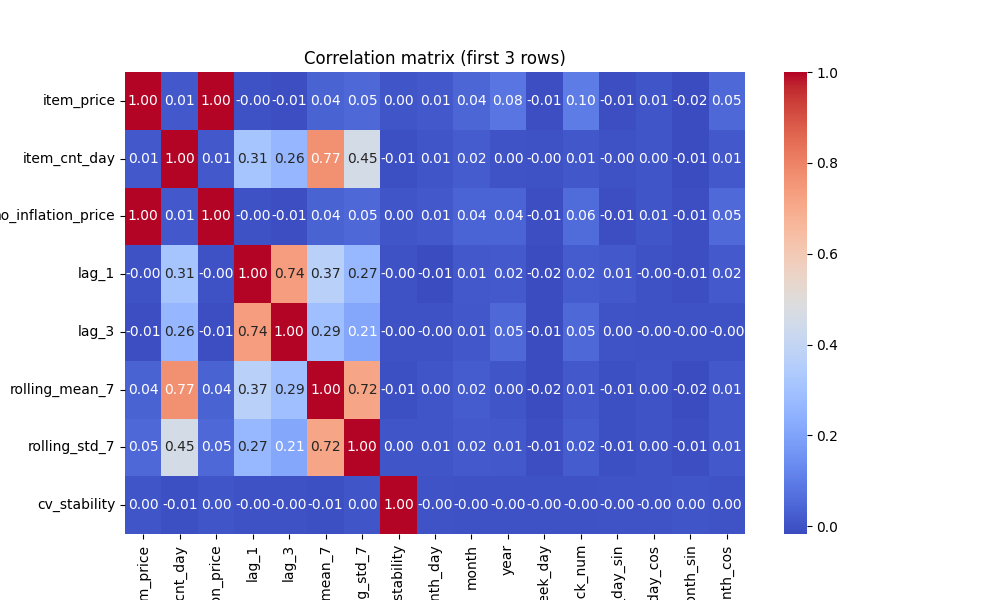

In [90]:
numeric_cols = ['item_price', 'item_cnt_day', 'no_inflation_price','lag_1', 'lag_3', 'rolling_mean_7',
       'rolling_std_7', 'cv_stability', 'month_day', 'month', 'year', 'week_day', 'date_block_num', 'month_day_sin', 'month_day_cos', 'month_sin', 'month_cos']
corr = df_final[numeric_cols].corr()
corr_subset = corr.iloc[:8, :]

plt.figure(figsize=(10, 6))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix (first 3 rows)')

plt.show()

Features representing sales in the previous month and the previous three months were added.

Also were added mean and std for nearest 7 days and coefficient of variation.

These features will allow model to capture:

- trends;
- seasonality;
- sales inertia;
- past product popularity.
- stability of sales

However, there is a problem with records at the beginning of the table where no historical data exists, as well as with products that appeared in a shop after January 2013, when data collection for the dataset began. And because of how sparse data is there are lots of zeros in this features.

# Summary

## What am I working with?

I am working with a time series of product sales in various shops that use 1C software for sales accounting.

The data contains:

- sales information;
- products and categories;
- shops;
- time-related features.

The main task is to predict product sales in future months.

## What are the main patterns in the data?

The data shows:

- strong seasonality;
- increased sales in December;
- an overall trend of decline in sales over time;
- dependence on the day of the week;
- large differences between shops;
- large differences between product categories;
- high sparsity of product-shop combinations.

## How do the data entities interact?

Sales depend simultaneously on:

- shop;
- product;
- category;
- year;
- month;
- day of week;
- day of month;
- city.

The same product may sell differently in different shops, and it may also sell differently in the same shop on different dates.

## What should be done to obtain good features?

- create lag features;
- account for seasonality;
- add city features and more date-related features;
- handle outliers;
- remove or correct data errors.
- create more time-series features.

## What problems arise during forecasting?

Main difficulties:

- a large number of outliers;
- infrequent sales;
- data sparsity;
- new products and shops;
- strong seasonality;
- online shops;
- items from the 'Software' category.

These issues make the forecasting task fairly difficult.

## How can forecasts be made manually?

The simplest approach is to use sales from previous months.

For example:

- use the prediction from the previous month;
- use the sum of predictions from previous months with different coefficients;
- use average sales of the product in other cities during previous months if the product has not previously been sold in the current city.

Past sales values are the primary source of information for forecasting.